<div style="background: linear-gradient(160deg, #0d1117 0%, #1a1a2e 60%, #16213e 100%);
     padding: 60px 48px 48px 48px; border-radius: 16px;
     border-left: 8px solid #e94560; margin-bottom: 8px;">
  <p style="color:#e94560; font-size:1.05em; letter-spacing:0.18em; margin:0 0 12px 0; font-weight:700;">
    ASHIRA &nbsp;·&nbsp; HackODS UNAM 2026 &nbsp;·&nbsp; ODS 1 + ODS 10
  </p>
  <h1 style="color:white; font-size:3em; font-weight:900; line-height:1.15; margin:0 0 20px 0;">
    En México no se puede hablar de pobreza<br>
    sin hablar de <span style="color:#e94560;">dónde naciste.</span>
  </h1>
  <p style="color:#a0a8b8; font-size:1.2em; line-height:1.7; margin:0 0 28px 0; max-width:780px;">
    Un análisis de datos abiertos que cruza cuatro fuentes nacionales para demostrar
    que en México, el código postal al nacer predice con mayor fuerza que el esfuerzo
    individual si una persona vivirá en pobreza.
  </p>
  <p style="color:#e94560; font-size:1.05em; font-weight:600; margin:0;">
    ASHIRA &nbsp;·&nbsp; HackODS UNAM 2026 &nbsp;·&nbsp; ODS 1 + ODS 10
  </p>
</div>

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
import openpyxl
from pathlib import Path
import sys

# Rutas — el notebook vive en Ashira/dashboard/, los datos en hackods/
# Subimos dos niveles: dashboard/ → Ashira/ → hackods/
_HERE  = Path(".").resolve()
ROOT   = _HERE.parent.parent if (_HERE.parent.parent / "Posibles Datos Melisa").exists()          else _HERE.parent    # fallback si se corre desde otro directorio

MELISA = ROOT / "Posibles Datos Melisa" / "HackODS"
ISRAEL = ROOT / "Posibles Datos Israel (falta analizar y sacar insights)"
JHOSHUA= ROOT / "Posibles Datos Jhoshua"
REPO   = _HERE.parent        # Ashira/ — para acceder a datos/shapefiles
IMG    = Path("imagenes"); IMG.mkdir(exist_ok=True)

sys.path.insert(0, str(ISRAEL / "scripts"))
from parse_censo import extraer_valores_estado, REGIONES as REGIONES_CENSO, ESTADOS_CORTOS

# Paleta de colores
BG      = "#0d1117"
CARD    = "#161b22"
ACCENT  = "#e94560"
GOLD    = "#f5a623"
TEAL    = "#0f9b8e"
PURPLE  = "#7b68ee"
GREEN   = "#2ecc71"
MUTED   = "#8b949e"

REGION_COLORS = {"Norte": TEAL, "Centro": GOLD, "Sur": ACCENT, "CDMX": PURPLE}

REGIONES = {
    "Aguascalientes":"Centro","Baja California":"Norte","Baja California Sur":"Norte",
    "Campeche":"Sur","Coahuila":"Norte","Colima":"Centro","Chiapas":"Sur",
    "Chihuahua":"Norte","Ciudad de México":"CDMX","Durango":"Norte",
    "Guanajuato":"Centro","Guerrero":"Sur","Hidalgo":"Centro","Jalisco":"Centro",
    "México":"Centro","Michoacán":"Centro","Morelos":"Centro","Nayarit":"Norte",
    "Nuevo León":"Norte","Oaxaca":"Sur","Puebla":"Centro","Querétaro":"Centro",
    "Quintana Roo":"Sur","San Luis Potosí":"Norte","Sinaloa":"Norte","Sonora":"Norte",
    "Tabasco":"Sur","Tamaulipas":"Norte","Tlaxcala":"Centro","Veracruz":"Sur",
    "Yucatán":"Sur","Zacatecas":"Norte",
}

# Estilos globales
plt.rcParams.update({
    "figure.facecolor":  BG,   "axes.facecolor":    CARD,
    "text.color":        "white", "axes.labelcolor": "white",
    "xtick.color":       "white", "ytick.color":     "white",
    "axes.spines.top":   False,   "axes.spines.right":False,
    "axes.spines.left":  False,   "axes.spines.bottom":False,
    "axes.titlesize":    22,   "axes.labelsize":    16,
    "xtick.labelsize":   14,   "ytick.labelsize":   14,
    "legend.fontsize":   13,   "legend.framealpha": 0.25,
    "figure.titlesize":  24,   "figure.dpi":        130,
})

ESTADOS_ENIGH = {
    1:"Aguascalientes",2:"Baja California",3:"Baja California Sur",4:"Campeche",
    5:"Coahuila",6:"Colima",7:"Chiapas",8:"Chihuahua",9:"Ciudad de México",
    10:"Durango",11:"Guanajuato",12:"Guerrero",13:"Hidalgo",14:"Jalisco",
    15:"México",16:"Michoacán",17:"Morelos",18:"Nayarit",19:"Nuevo León",
    20:"Oaxaca",21:"Puebla",22:"Querétaro",23:"Quintana Roo",24:"San Luis Potosí",
    25:"Sinaloa",26:"Sonora",27:"Tabasco",28:"Tamaulipas",29:"Tlaxcala",
    30:"Veracruz",31:"Yucatán",32:"Zacatecas",
}

def wmean(x, w):
    w = np.asarray(w, dtype=float)
    return np.average(x, weights=w) if w.sum() > 0 else np.nan

def wmedian(vals, weights):
    s = sorted(zip(weights, vals))
    wt = sum(w for w, _ in s)
    cum = 0
    for w, v in s:
        cum += w
        if cum >= wt / 2:
            return v
    return float("nan")

print("Configuración lista.")
print(f"ROOT   : {ROOT}")
print(f"MELISA : {MELISA}  {'✓' if MELISA.exists() else '✗ NO ENCONTRADO'}")
print(f"ISRAEL : {ISRAEL}  {'✓' if ISRAEL.exists() else '✗ NO ENCONTRADO'}")
print(f"JHOSHUA: {JHOSHUA}  {'✓' if JHOSHUA.exists() else '✗ NO ENCONTRADO'}")


Configuración lista.
ROOT   : C:\Users\Jhoshua\OneDrive\Documentos\Ciencia de Datos\Hackathones\hackods
MELISA : C:\Users\Jhoshua\OneDrive\Documentos\Ciencia de Datos\Hackathones\hackods\Posibles Datos Melisa\HackODS  ✓
ISRAEL : C:\Users\Jhoshua\OneDrive\Documentos\Ciencia de Datos\Hackathones\hackods\Posibles Datos Israel (falta analizar y sacar insights)  ✓
JHOSHUA: C:\Users\Jhoshua\OneDrive\Documentos\Ciencia de Datos\Hackathones\hackods\Posibles Datos Jhoshua  ✓


<div style="background:#161b22; padding:28px 36px; border-radius:12px;
     border-left:5px solid #f5a623; margin:16px 0;">
  <h2 style="color:#f5a623; margin:0 0 10px 0; font-size:1.7em;">Cargando las tres capas de evidencia</h2>
  <p style="color:#a0a8b8; margin:0; font-size:1.1em;">
    ENIGH 2016–2024 (Melisa) · Censo 2020 (Israel) · ICE IMCO 2016–2018 (Israel) · Pobreza Multidimensional 2024 (Jhoshua)
  </p>
</div>

In [ ]:
norte_ing = enigh_reg[(enigh_reg["region"]=="Norte") & (enigh_reg["anio"]==2024)]["ing_pc_mediana"].values[0]
sur_ing   = enigh_reg[(enigh_reg["region"]=="Sur")   & (enigh_reg["anio"]==2024)]["ing_pc_mediana"].values[0]
ratio_ns  = norte_ing / sur_ing

PM 2024: 32 estados  |  Chiapas: 66.0%  |  BC: 9.9%
  ENIGH 2016: 70,311 hogares
  ENIGH 2018: 74,647 hogares
  ENIGH 2020: 89,006 hogares
  ENIGH 2022: 90,102 hogares
  ENIGH 2024: 91,414 hogares

ENIGH agregada: 160 filas estado-año
Censo 2020: 32 estados
ICE 2018: 32 estados

Dataset maestro: 32 estados · ['estado', 'pct_pobreza_2024', 'region', 'pob_educ_superior', 'pct_indigena', 'pct_inseg_alim', 'ice_informalidad', 'ice_migracion', 'ing_pc_mediana', 'pct_bene_gob', 'pct_remesas', 'pct_ingtrab', 'color']

Stats cierre:
  Brecha Chiapas-BC: 56.1 pts  (markdown dice ~56)
  Ratio Norte/Sur ingreso 2024: 0.51×  (markdown dice 1.4×)
  Estados con pobreza >40%%: 6  (usado en cierre)


<div style="background:#0d1117; padding:36px 44px; border-radius:14px;
     border: 1px solid #30363d; margin:24px 0 8px 0;">
  <h2 style="color:white;font-size:2em;font-weight:900;margin:0 0 14px 0;">
    El mapa que el promedio no te muestra
  </h2>
  <p style="color:#c9d1d9;font-size:1.1em;line-height:1.7;margin:0;">
    Cada estado coloreado por su porcentaje de pobreza multidimensional en 2024.
    El patrón es inmediato: el sur es rojo, el norte es verde.
    No hay excepciones. No hay ambigüedad.
    <strong style="color:#e94560;">La geografía del nacimiento es la geografía de la pobreza.</strong>
  </p>
</div>

Estados con datos: 32/32


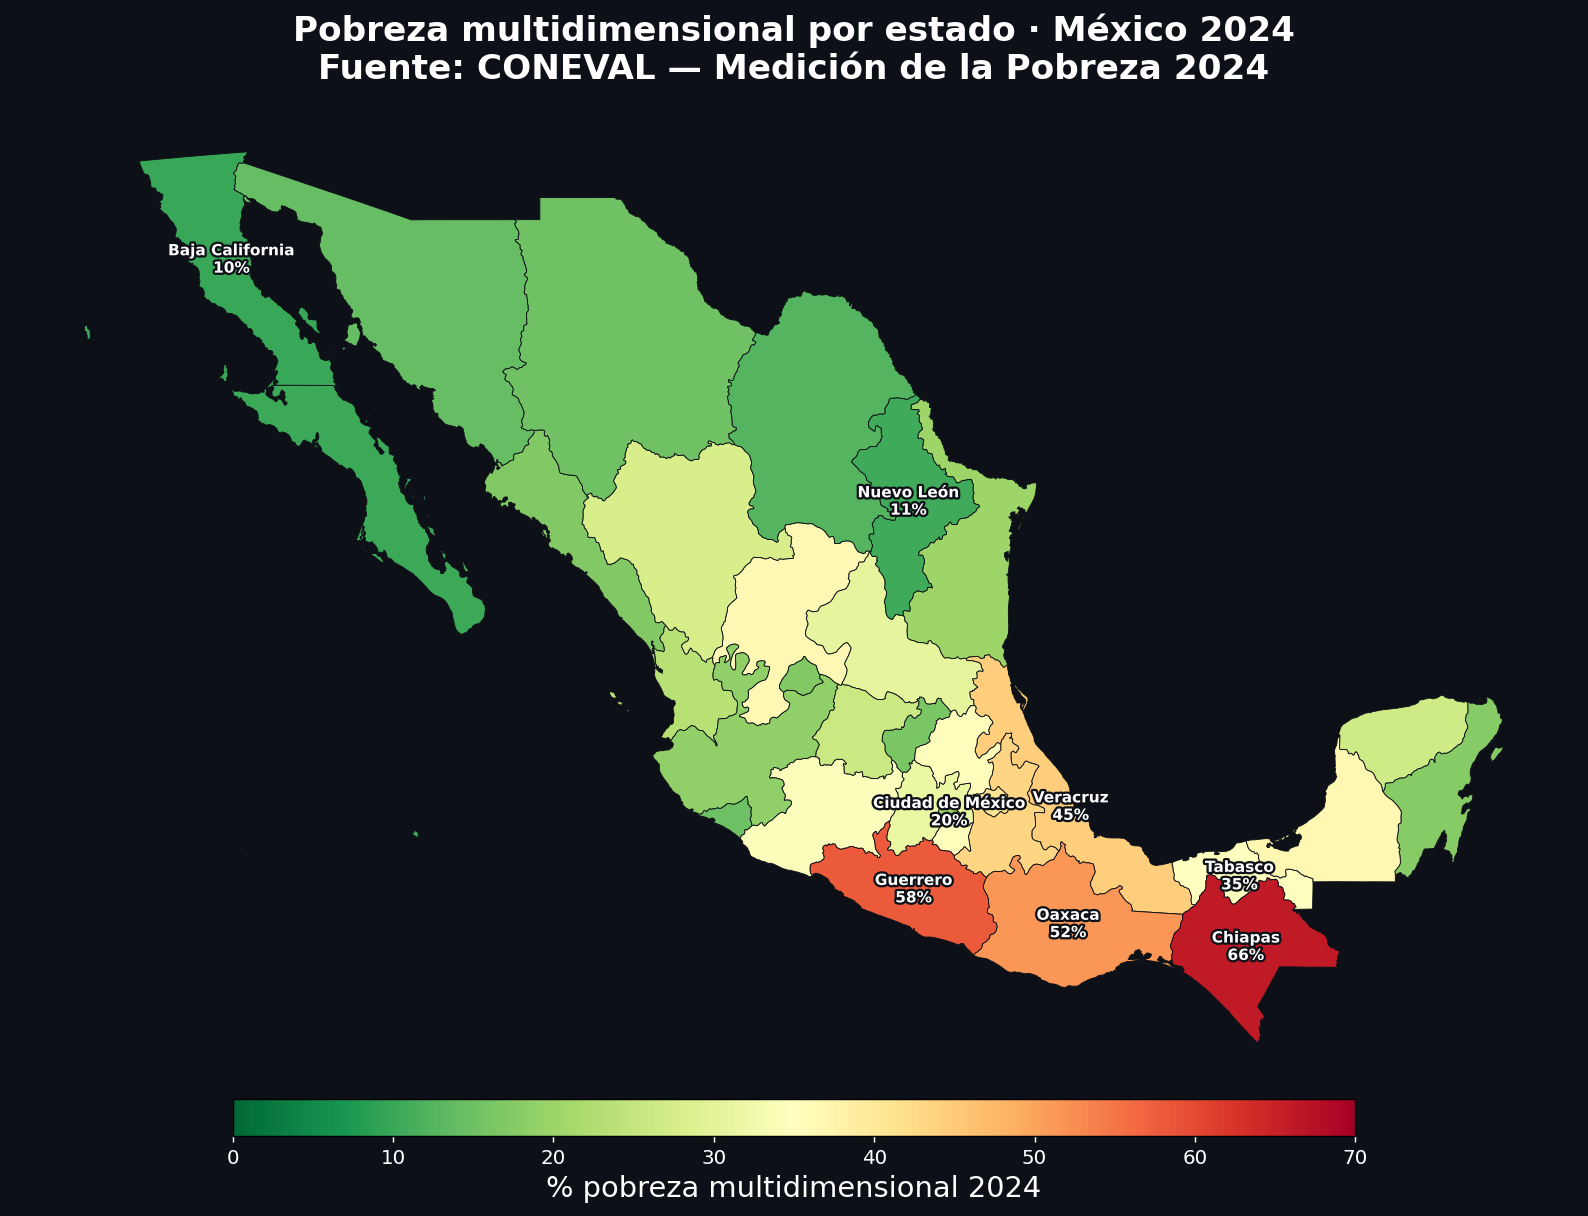

In [4]:
import unicodedata, geopandas as gpd

def norm(s):
    return unicodedata.normalize("NFD", str(s)).encode("ascii","ignore").decode().lower().strip()

GEO_PATH = REPO / "datos" / "shapefiles" / "mexico_estados.geojson"
gdf = gpd.read_file(GEO_PATH)

# Mapping robusto por nombre normalizado
GEO_NAME_FIX = {
    "mexico":                   "México",
    "michoacan de ocampo":      "Michoacán",
    "coahuila de zaragoza":     "Coahuila",
    "veracruz de ignacio de la llave": "Veracruz",
    "ciudad de mexico":         "Ciudad de México",
    "distrito federal":         "Ciudad de México",
    "nuevo leon":               "Nuevo León",
    "queretaro":                "Querétaro",
    "san luis potosi":          "San Luis Potosí",
    "yucatan":                  "Yucatán",
    "michoacan":                "Michoacán",
    "coahuila":                 "Coahuila",
}

std_by_norm = {norm(e): e for e in maestro["estado"].unique()}

def geo_to_std(geo_name):
    n = norm(geo_name)
    if n in GEO_NAME_FIX:
        return GEO_NAME_FIX[n]
    return std_by_norm.get(n, geo_name)

gdf["estado_std"] = gdf["name"].apply(geo_to_std)
gdf = gdf.merge(maestro[["estado","pct_pobreza_2024","region"]], left_on="estado_std", right_on="estado", how="left")

matched = gdf["pct_pobreza_2024"].notna().sum()
print(f"Estados con datos: {matched}/32")

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.axis("off")

gdf.plot(
    column="pct_pobreza_2024",
    ax=ax,
    cmap="RdYlGn_r",
    linewidth=0.5,
    edgecolor="#0d1117",
    legend=True,
    legend_kwds={
        "label": "% pobreza multidimensional 2024",
        "orientation": "horizontal",
        "shrink": 0.55,
        "pad": 0.01,
        "aspect": 30,
    },
    missing_kwds={"color": "#30363d", "label": "Sin dato"},
    vmin=0, vmax=70,
)

# Etiquetas para estados clave
LABEL_STATES = {"Guerrero","Chiapas","Oaxaca","Veracruz","Nuevo León","Baja California","Ciudad de México","Tabasco"}
for _, row in gdf.iterrows():
    if row["estado"] in LABEL_STATES and row.geometry is not None:
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        porc = row["pct_pobreza_2024"]
        if pd.notna(porc):
            ax.annotate(
                f"{row['estado']}\n{porc:.0f}%",
                (cx, cy),
                ha="center", va="center",
                fontsize=8.5, color="white", fontweight="bold",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="#0d1117")],
            )

ax.set_title("Pobreza multidimensional por estado · México 2024\n"
             "Fuente: CONEVAL — Medición de la Pobreza 2024",
             fontsize=19, fontweight="bold", color="white", pad=16)

cbar = ax.get_figure().axes[-1]
cbar.tick_params(colors="white", labelsize=11)
cbar.yaxis.label.set_color("white")
plt.setp(cbar.get_xticklabels(), color="white")

plt.tight_layout()
plt.savefig(IMG/"00_mapa_pobreza.png", dpi=150, bbox_inches="tight",
            facecolor=BG)
plt.show()


<div style="background:linear-gradient(135deg,#1a1a2e,#16213e);
     padding:36px 44px; border-radius:14px; border-left:7px solid #e94560; margin:24px 0 8px 0;">
  <p style="color:#e94560;font-weight:700;letter-spacing:.15em;font-size:.95em;margin:0 0 8px 0;">ACTO I</p>
  <h2 style="color:white;font-size:2.1em;font-weight:900;margin:0 0 16px 0;">
    Los dos Méxicos que el promedio esconde
  </h2>
  <p style="color:#c9d1d9;font-size:1.15em;line-height:1.75;margin:0;">
    México reporta avances. Las cifras nacionales mejoran. Pero detrás del promedio vive una
    contradicción brutal: en <strong style="color:#e94560;">Chiapas</strong>, dos de cada tres personas
    son pobres. En <strong style="color:#0f9b8e;">Baja California</strong>, menos de una de cada diez.
    Y esto sucede en un mismo país.
  </p>
</div>

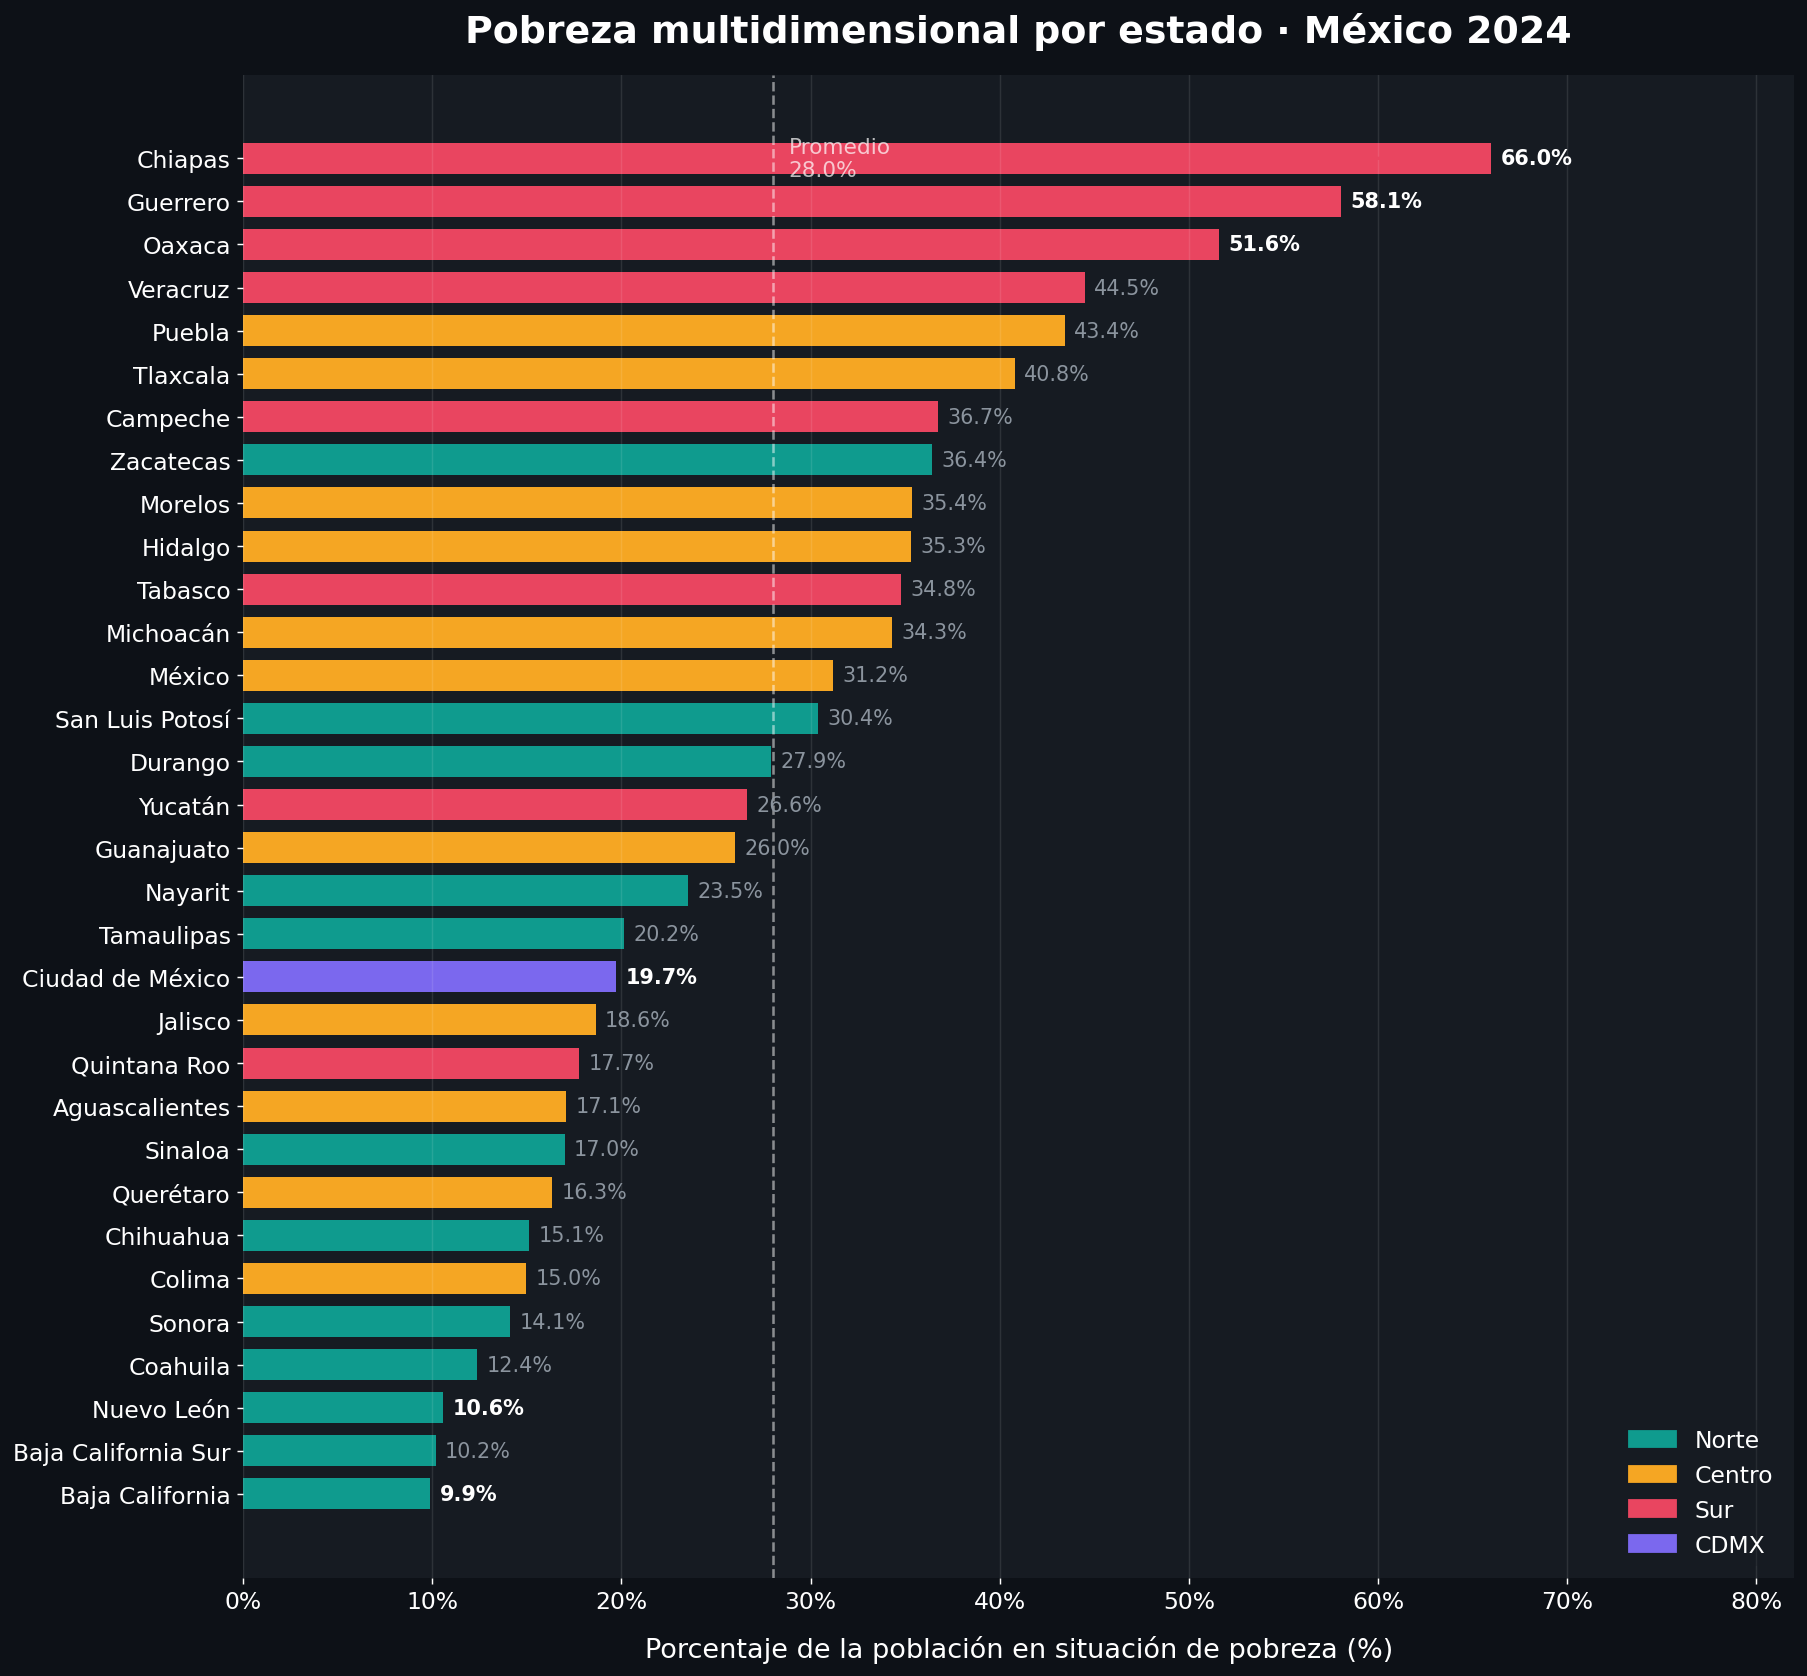

Brecha: 66.0% – 9.9% = 56.1 puntos


In [5]:
fig, ax = plt.subplots(figsize=(14, 13))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

df_plot = maestro.dropna(subset=["pct_pobreza_2024"]).sort_values("pct_pobreza_2024", ascending=True)
colors  = [REGION_COLORS.get(r, MUTED) for r in df_plot["region"]]

bars = ax.barh(df_plot["estado"], df_plot["pct_pobreza_2024"],
               color=colors, edgecolor="none", height=0.72)

# Línea del promedio nacional
nac = df_plot["pct_pobreza_2024"].mean()
ax.axvline(nac, color="white", linewidth=1.4, linestyle="--", alpha=0.5)
ax.text(nac + 0.8, len(df_plot)-0.5, f"Promedio\n{nac:.1f}%",
        color="white", fontsize=12, va="top", alpha=0.7)

# Valores al final de cada barra
for bar, val, estado in zip(bars, df_plot["pct_pobreza_2024"], df_plot["estado"]):
    destacado = estado in ("Chiapas","Guerrero","Oaxaca","Nuevo León","Baja California","Ciudad de México")
    color_txt = "white" if destacado else MUTED
    fw = "bold" if destacado else "normal"
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", ha="left", fontsize=11.5,
            color=color_txt, fontweight=fw)

# Anotaciones especiales
for _, row in df_plot[df_plot["estado"].isin(["Chiapas","Guerrero"])].iterrows():
    idx = list(df_plot["estado"]).index(row["estado"])
    ax.annotate("", xy=(row["pct_pobreza_2024"]-1, idx),
                xytext=(row["pct_pobreza_2024"]-8, idx),
                arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.8))

ax.set_xlabel("Porcentaje de la población en situación de pobreza (%)", fontsize=15, labelpad=12)
ax.set_title("Pobreza multidimensional por estado · México 2024",
             fontsize=21, fontweight="bold", pad=18)
ax.set_xlim(0, 82)
ax.tick_params(axis="y", labelsize=13)
ax.tick_params(axis="x", labelsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.grid(axis="x", alpha=0.1, color="white", linewidth=0.8)

handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax.legend(handles=handles, loc="lower right", fontsize=13,
          framealpha=0.3, edgecolor="none")

plt.tight_layout()
plt.savefig(IMG/"01_pobreza_estados.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Brecha: {df_plot.iloc[-1]['pct_pobreza_2024']:.1f}% – {df_plot.iloc[0]['pct_pobreza_2024']:.1f}% = {df_plot.iloc[-1]['pct_pobreza_2024']-df_plot.iloc[0]['pct_pobreza_2024']:.1f} puntos")


<div style="background:linear-gradient(135deg,#1a1a2e,#16213e);
     padding:36px 44px; border-radius:14px; border-left:7px solid #f5a623; margin:24px 0 8px 0;">
  <p style="color:#f5a623;font-weight:700;letter-spacing:.15em;font-size:.95em;margin:0 0 8px 0;">ACTO II</p>
  <h2 style="color:white;font-size:2.1em;font-weight:900;margin:0 0 16px 0;">
    La brecha que no cierra
  </h2>
  <p style="color:#c9d1d9;font-size:1.15em;line-height:1.75;margin:0;">
    Entre 2016 y 2024, el ingreso en México creció. Pero no para todos por igual.
    Mientras el Norte avanzó, el Sur se quedó en el mismo lugar.
    La pandemia de 2020 golpeó a todos — pero al Sur le costó más recuperarse.
    Ocho años de datos. Una sola conclusión: <strong style="color:#f5a623;">el origen sigue siendo destino.</strong>
  </p>
</div>

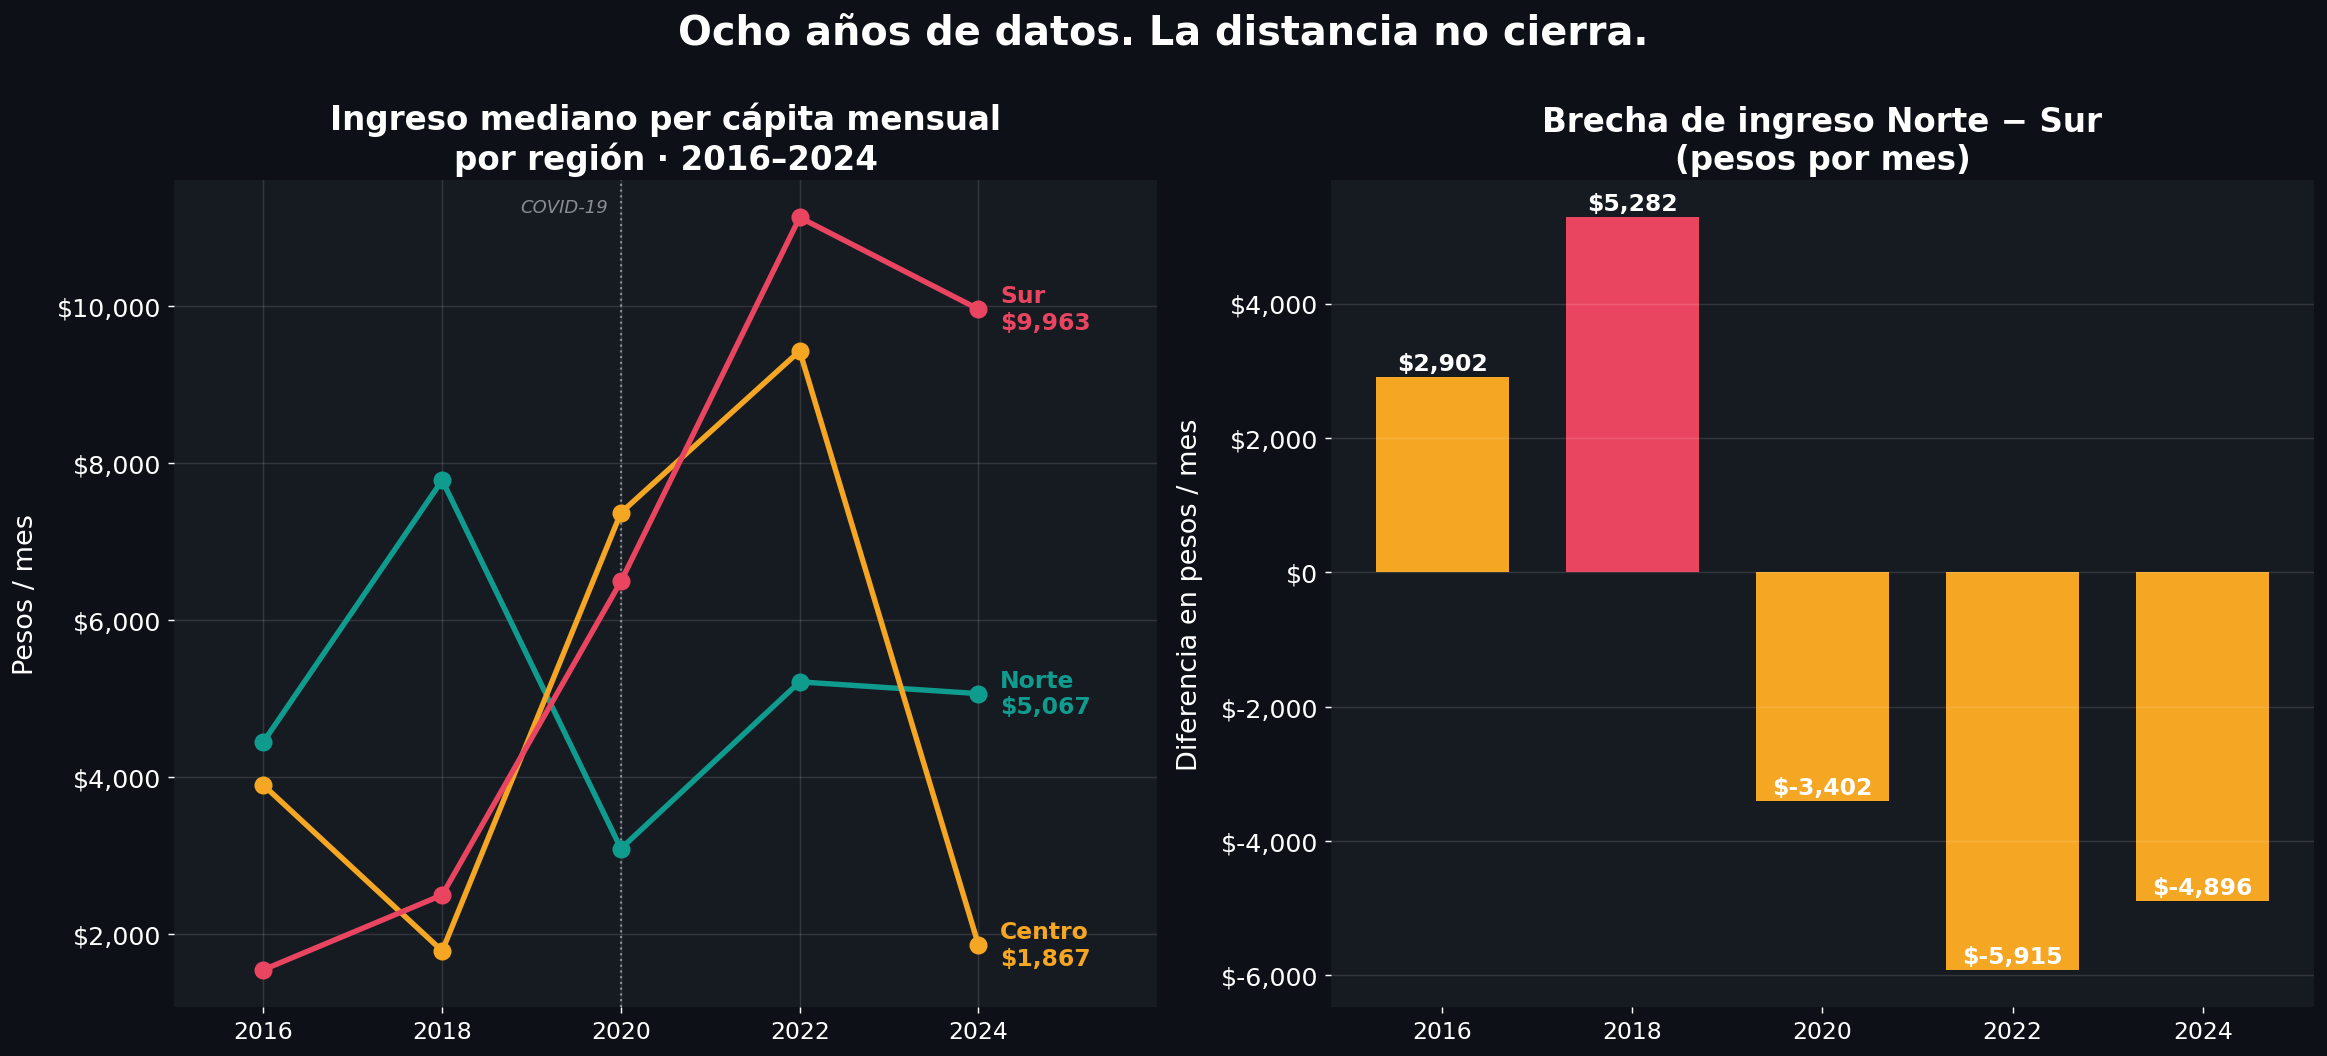

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(BG)
años = [2016, 2018, 2020, 2022, 2024]

# Panel izquierdo: trayectorias por región
ax = axes[0]
ax.set_facecolor(CARD)
for region in ["Norte","Centro","Sur"]:
    sub = enigh_reg[enigh_reg["region"]==region].sort_values("anio")
    col = REGION_COLORS[region]
    ax.plot(sub["anio"], sub["ing_pc_mediana"], marker="o", color=col,
            linewidth=3, markersize=9, zorder=5)
    # Etiqueta al final de la línea
    ultimo = sub.iloc[-1]
    ax.annotate(f"{region}\n${ultimo['ing_pc_mediana']:,.0f}",
                xy=(ultimo["anio"], ultimo["ing_pc_mediana"]),
                xytext=(12, 0), textcoords="offset points",
                color=col, fontsize=13, fontweight="bold", va="center")

ax.set_title("Ingreso mediano per cápita mensual\npor región · 2016–2024",
             fontsize=18, fontweight="bold")
ax.set_ylabel("Pesos / mes", fontsize=15, labelpad=10)
ax.set_xticks(años)
ax.set_xticklabels([str(a) for a in años], fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.grid(alpha=0.12, color="white")
ax.set_xlim(2015, 2026)
ax.axvline(2020, color="white", linewidth=1.2, linestyle=":", alpha=0.45)
ax.text(2019.85, ax.get_ylim()[1]*0.98, "COVID-19", color="white", fontsize=10,
        alpha=0.5, ha="right", va="top", style="italic")

# Panel derecho: brecha Norte-Sur
ax2 = axes[1]
ax2.set_facecolor(CARD)
norte_vals = enigh_reg[enigh_reg["region"]=="Norte"].sort_values("anio")["ing_pc_mediana"].values
sur_vals   = enigh_reg[enigh_reg["region"]=="Sur"].sort_values("anio")["ing_pc_mediana"].values
brecha = norte_vals - sur_vals

bars2 = ax2.bar(años, brecha,
                color=[ACCENT if b == max(brecha) else GOLD for b in brecha],
                edgecolor="none", width=1.4)

for bar, val in zip(bars2, brecha):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
             f"${val:,.0f}", ha="center", va="bottom",
             fontsize=13, fontweight="bold", color="white")

ax2.set_title("Brecha de ingreso Norte − Sur\n(pesos por mes)", fontsize=18, fontweight="bold")
ax2.set_ylabel("Diferencia en pesos / mes", fontsize=15, labelpad=10)
ax2.set_xticks(años)
ax2.set_xticklabels([str(a) for a in años], fontsize=13)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax2.grid(axis="y", alpha=0.12, color="white")

fig.suptitle("Ocho años de datos. La distancia no cierra.",
             fontsize=22, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(IMG/"02_trayectorias_brecha.png", dpi=150, bbox_inches="tight")
plt.show()


<div style="background:linear-gradient(135deg,#1a1a2e,#16213e);
     padding:36px 44px; border-radius:14px; border-left:7px solid #7b68ee; margin:24px 0 8px 0;">
  <p style="color:#7b68ee;font-weight:700;letter-spacing:.15em;font-size:.95em;margin:0 0 8px 0;">ACTO III</p>
  <h2 style="color:white;font-size:2.1em;font-weight:900;margin:0 0 16px 0;">
    Las raíces: por qué el sur es pobre
  </h2>
  <p style="color:#c9d1d9;font-size:1.15em;line-height:1.75;margin:0;">
    La pobreza en México no es aleatoria. Tiene raíces en la historia, en la etnicidad,
    en el mercado de trabajo. Dos correlaciones que incomodan porque no tienen
    explicación inocente: más población indígena, más pobreza. Más informalidad, menos ingreso.
    <strong style="color:#7b68ee;">No es coincidencia. Es estructura.</strong>
  </p>
</div>

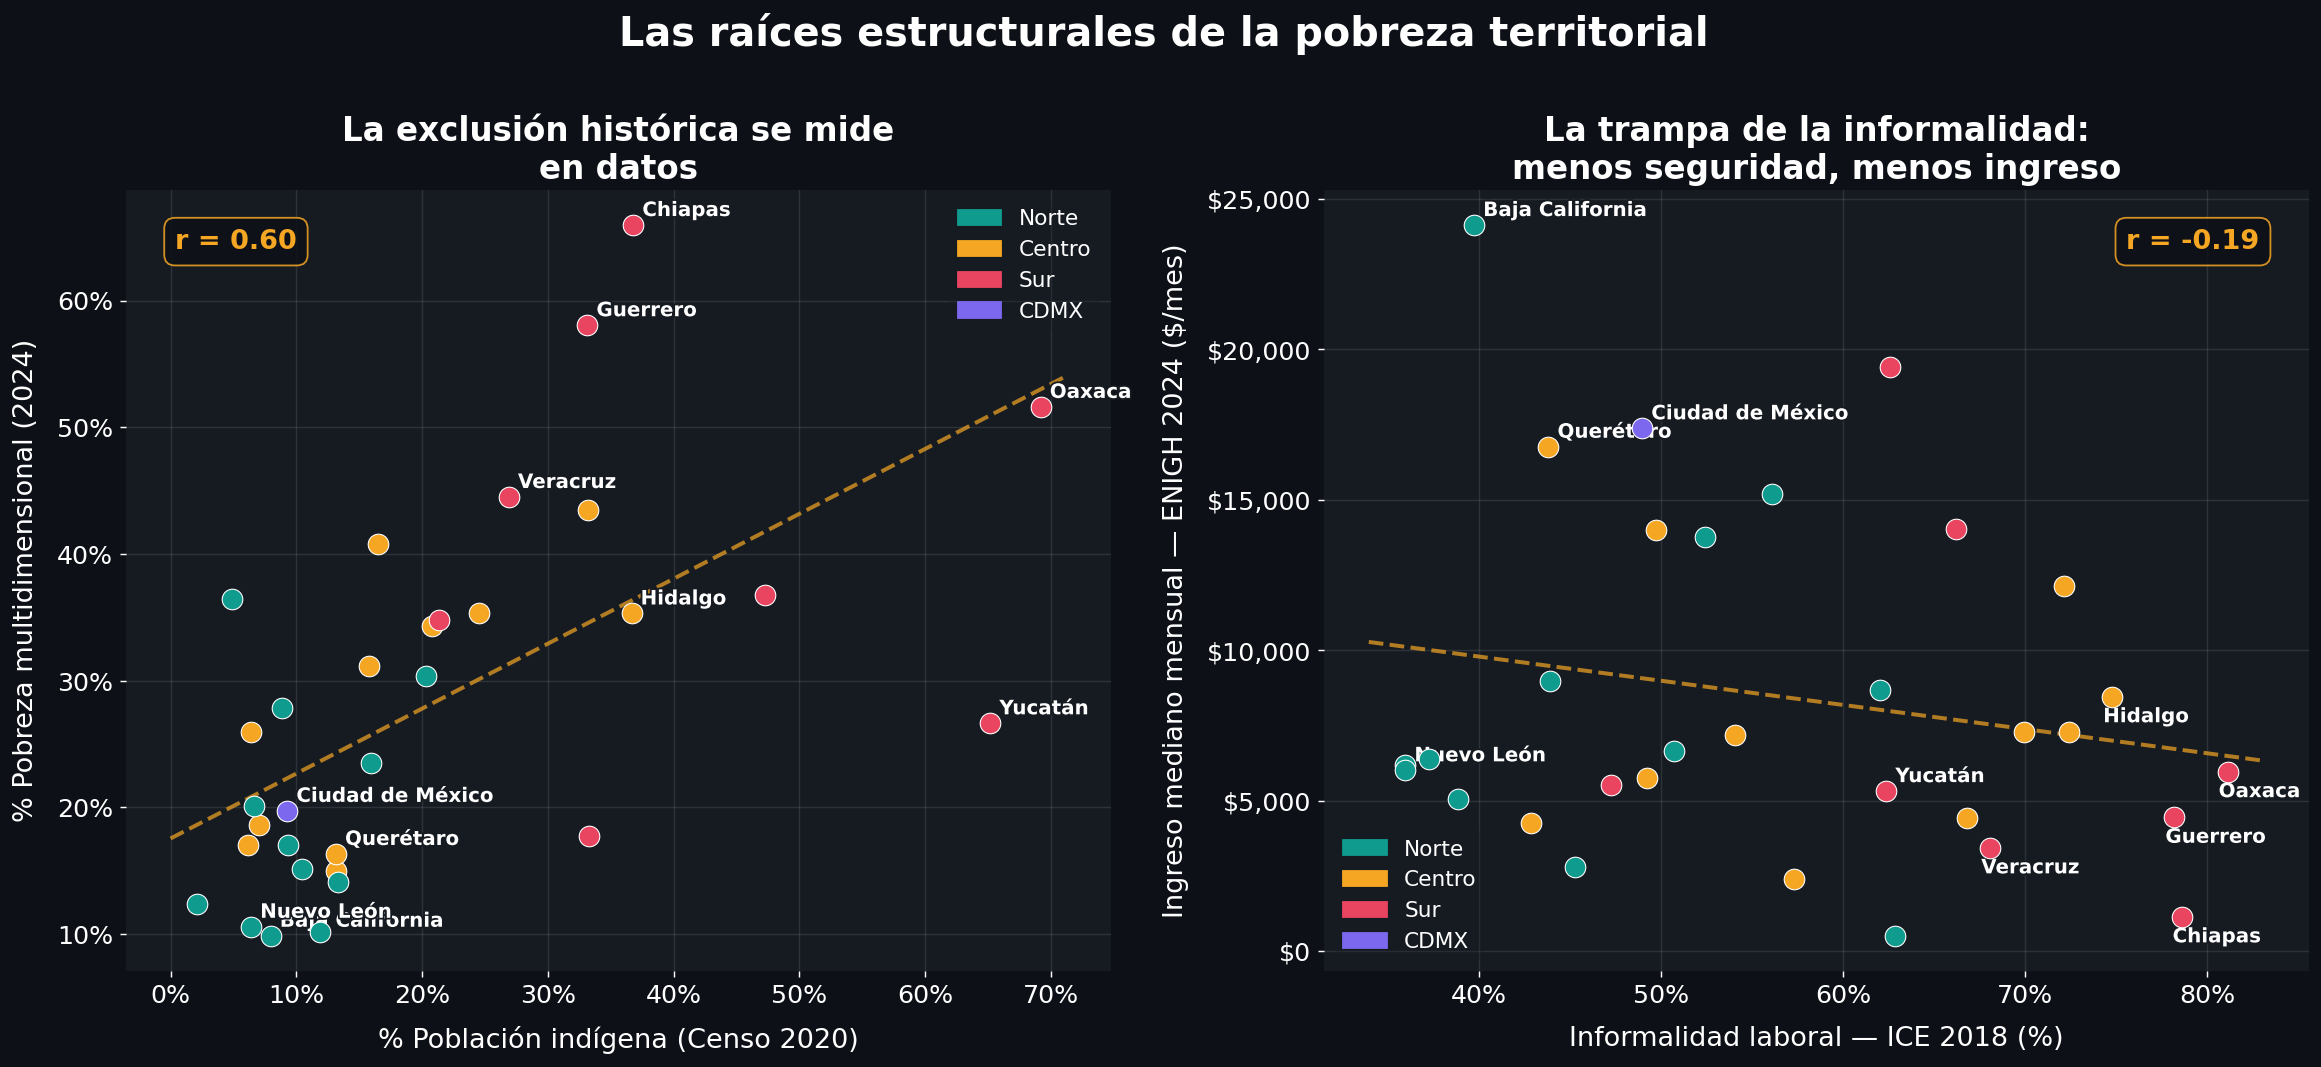

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(BG)

# Panel izquierdo: % indigena vs % pobreza (Censo 2020 × PM 2024)
ax = axes[0]
ax.set_facecolor(CARD)
df_etnia_pm = maestro.dropna(subset=["pct_indigena","pct_pobreza_2024"])

# Solo etiquetar estados extremos o narrativamente relevantes
ETIQUETAR = {"Chiapas","Guerrero","Oaxaca","Nuevo León","Baja California",
             "Yucatán","Hidalgo","Querétaro","Veracruz","Ciudad de México"}

for _, row in df_etnia_pm.iterrows():
    ax.scatter(row["pct_indigena"], row["pct_pobreza_2024"],
               c=row["color"], s=130, zorder=5, edgecolors="white", linewidth=0.6)
    if row["estado"] in ETIQUETAR:
        offset = (5, 5) if row["pct_indigena"] < 70 else (-5, -12)
        ax.annotate(row["estado"],
                    (row["pct_indigena"], row["pct_pobreza_2024"]),
                    xytext=offset, textcoords="offset points",
                    fontsize=11, color="white", fontweight="bold",
                    path_effects=[pe.withStroke(linewidth=2, foreground=CARD)])

z = np.polyfit(df_etnia_pm["pct_indigena"], df_etnia_pm["pct_pobreza_2024"], 1)
x_l = np.linspace(0, df_etnia_pm["pct_indigena"].max()+2, 100)
ax.plot(x_l, np.poly1d(z)(x_l), "--", color=GOLD, alpha=0.7, linewidth=2.2)

corr = df_etnia_pm["pct_indigena"].corr(df_etnia_pm["pct_pobreza_2024"])
ax.text(0.05, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        fontsize=15, color=GOLD, va="top", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=BG, edgecolor=GOLD, alpha=0.85))

ax.set_xlabel("% Población indígena (Censo 2020)", fontsize=15, labelpad=10)
ax.set_ylabel("% Pobreza multidimensional (2024)", fontsize=15, labelpad=10)
ax.set_title("La exclusión histórica se mide\nen datos", fontsize=18, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.grid(alpha=0.1, color="white")

# Panel derecho: informalidad vs ingreso (ICE × ENIGH 2024)
ax2 = axes[1]
ax2.set_facecolor(CARD)
df_inf = maestro.dropna(subset=["ice_informalidad","ing_pc_mediana"])

for _, row in df_inf.iterrows():
    ax2.scatter(row["ice_informalidad"], row["ing_pc_mediana"],
                c=row["color"], s=130, zorder=5, edgecolors="white", linewidth=0.6)
    if row["estado"] in ETIQUETAR:
        offset = (5, 5) if row["ice_informalidad"] < 65 else (-5, -14)
        ax2.annotate(row["estado"],
                     (row["ice_informalidad"], row["ing_pc_mediana"]),
                     xytext=offset, textcoords="offset points",
                     fontsize=11, color="white", fontweight="bold",
                     path_effects=[pe.withStroke(linewidth=2, foreground=CARD)])

z2 = np.polyfit(df_inf["ice_informalidad"], df_inf["ing_pc_mediana"], 1)
x_l2 = np.linspace(df_inf["ice_informalidad"].min()-2, df_inf["ice_informalidad"].max()+2, 100)
ax2.plot(x_l2, np.poly1d(z2)(x_l2), "--", color=GOLD, alpha=0.7, linewidth=2.2)

corr2 = df_inf["ice_informalidad"].corr(df_inf["ing_pc_mediana"])
ax2.text(0.95, 0.95, f"r = {corr2:.2f}", transform=ax2.transAxes,
         fontsize=15, color=GOLD, va="top", ha="right", fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.4", facecolor=BG, edgecolor=GOLD, alpha=0.85))

ax2.set_xlabel("Informalidad laboral — ICE 2018 (%)", fontsize=15, labelpad=10)
ax2.set_ylabel("Ingreso mediano mensual — ENIGH 2024 ($/mes)", fontsize=15, labelpad=10)
ax2.set_title("La trampa de la informalidad:\nmenos seguridad, menos ingreso", fontsize=18, fontweight="bold")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax2.grid(alpha=0.1, color="white")

handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax.legend(handles=handles, fontsize=12, framealpha=0.25, edgecolor="none")
ax2.legend(handles=handles, fontsize=12, framealpha=0.25, edgecolor="none")

fig.suptitle("Las raíces estructurales de la pobreza territorial",
             fontsize=22, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(IMG/"03_raices_estructura.png", dpi=150, bbox_inches="tight")
plt.show()


<div style="background:#161b22; padding:24px 36px; border-radius:12px;
     border-left:5px solid #e94560; margin:8px 0 8px 0;">
  <p style="color:#c9d1d9;font-size:1.1em;line-height:1.7;margin:0;">
    La tercera raíz es la más concreta: el hambre.
    Los estados con mayor inseguridad alimentaria son exactamente los mismos
    con mayor pobreza y mayor población indígena.
    <strong style="color:#e94560;">En Guerrero y Oaxaca, más de la mitad de los hogares
    no tienen acceso seguro a los alimentos.</strong>
    Eso no es solo una estadística de ODS 2 — es el piso desde el que se construye
    (o no se construye) cualquier movilidad social.
  </p>
</div>

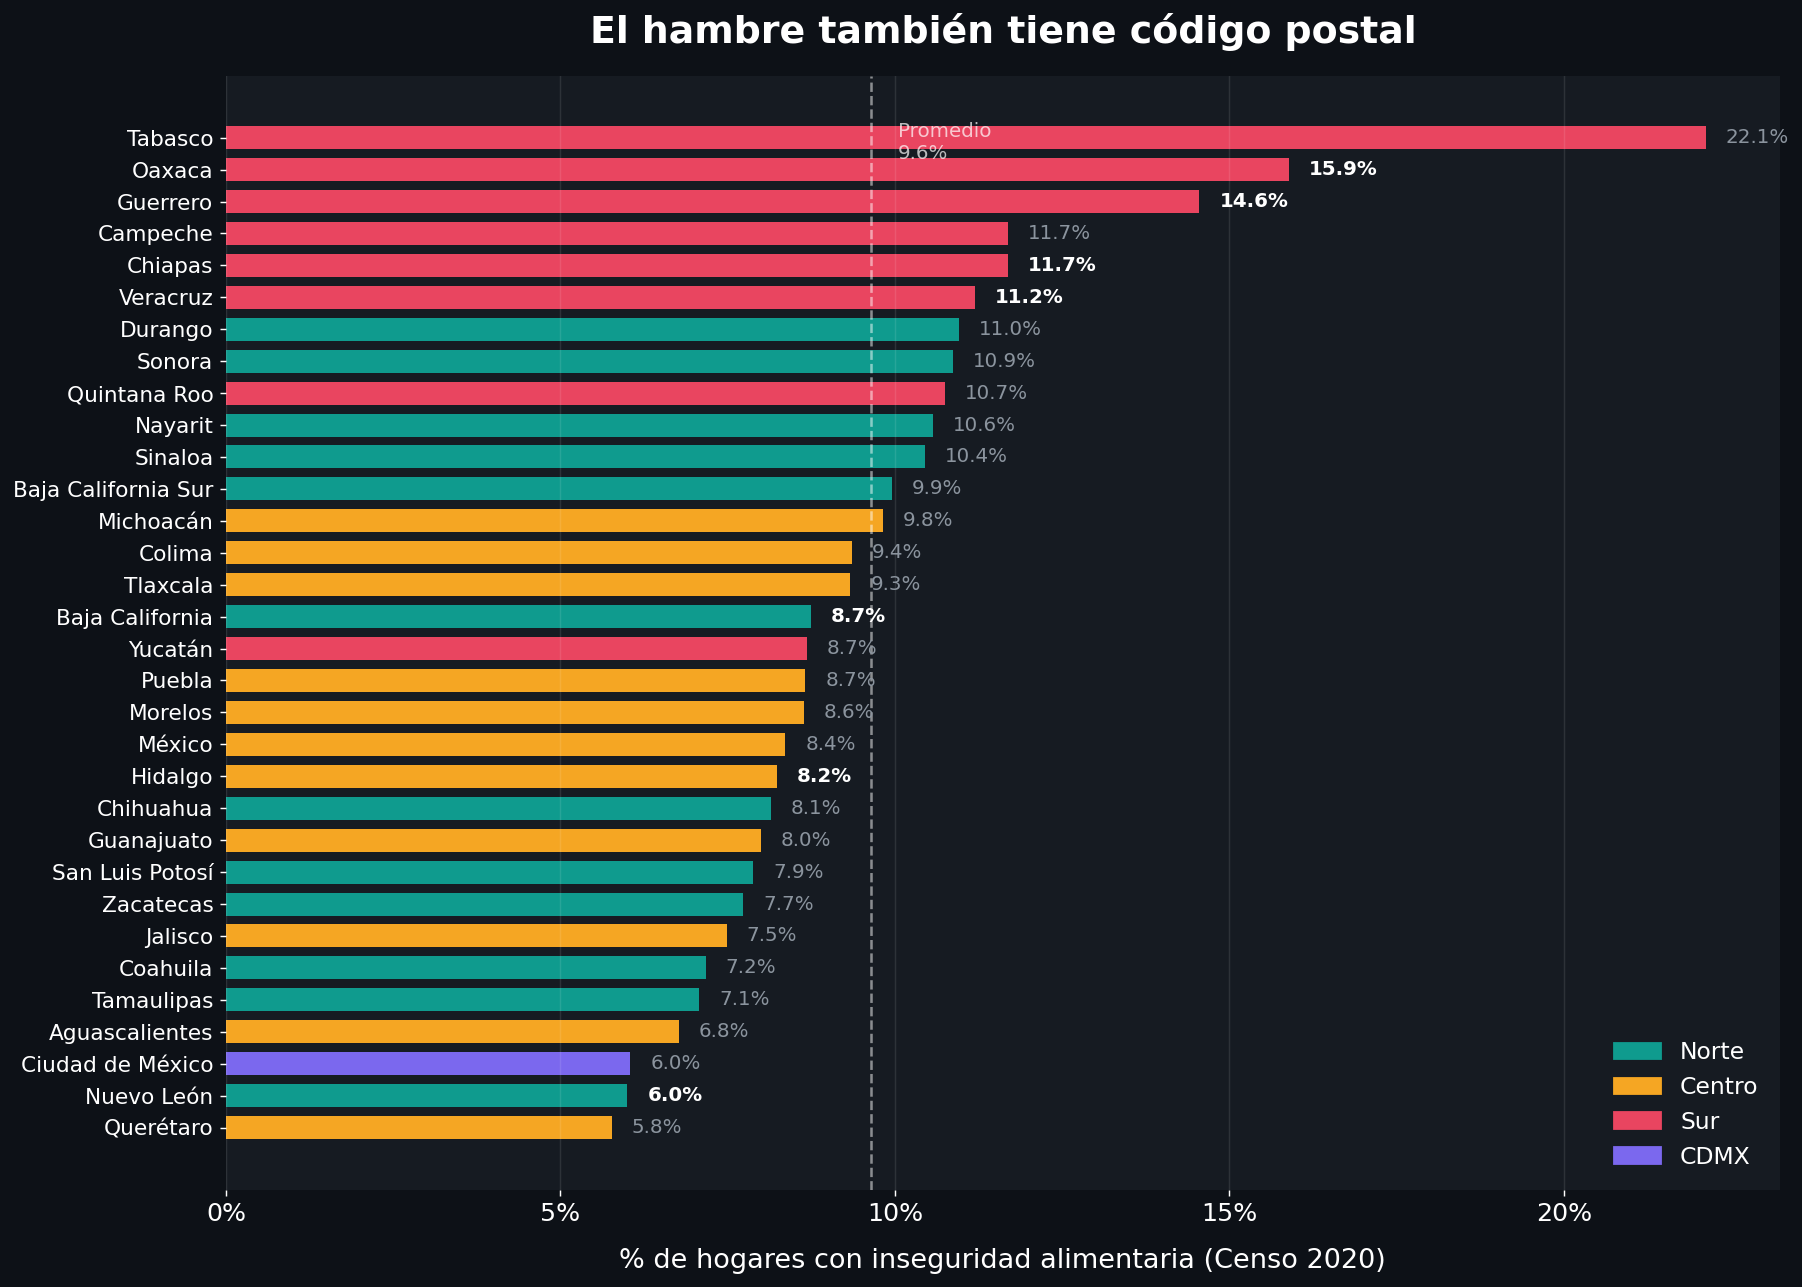

Top 3 inseguridad alimentaria:
  estado  pct_inseg_alim
 Tabasco       22.120023
  Oaxaca       15.890900
Guerrero       14.552084


In [8]:
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

df_alim_plot = maestro.dropna(subset=["pct_inseg_alim"]).sort_values("pct_inseg_alim", ascending=True)
colors_alim = [REGION_COLORS.get(r, MUTED) for r in df_alim_plot["region"]]

bars_alim = ax.barh(df_alim_plot["estado"], df_alim_plot["pct_inseg_alim"],
                    color=colors_alim, edgecolor="none", height=0.72)

nac_alim = df_alim_plot["pct_inseg_alim"].mean()
ax.axvline(nac_alim, color="white", linewidth=1.4, linestyle="--", alpha=0.5)
ax.text(nac_alim + 0.4, len(df_alim_plot) - 0.5,
        f"Promedio\n{nac_alim:.1f}%", color="white", fontsize=11, va="top", alpha=0.7)

DEST_ALIM = {"Guerrero","Oaxaca","Chiapas","Veracruz","Hidalgo","Nuevo León","Baja California"}
for bar, val, estado in zip(bars_alim, df_alim_plot["pct_inseg_alim"], df_alim_plot["estado"]):
    destacado = estado in DEST_ALIM
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", ha="left", fontsize=11,
            color="white" if destacado else MUTED,
            fontweight="bold" if destacado else "normal")

ax.set_xlabel("% de hogares con inseguridad alimentaria (Censo 2020)", fontsize=15, labelpad=12)
ax.set_title("El hambre también tiene código postal",
             fontsize=21, fontweight="bold", pad=18)
ax.tick_params(axis="y", labelsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.grid(axis="x", alpha=0.1, color="white", linewidth=0.8)

handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax.legend(handles=handles, loc="lower right", fontsize=13, framealpha=0.3, edgecolor="none")

plt.tight_layout()
plt.savefig(IMG/"03b_inseg_alim.png", dpi=150, bbox_inches="tight")
plt.show()
top3 = df_alim_plot.nlargest(3, "pct_inseg_alim")[["estado","pct_inseg_alim"]]
print("Top 3 inseguridad alimentaria:")
print(top3.to_string(index=False))


<div style="background:linear-gradient(135deg,#1a1a2e,#16213e);
     padding:36px 44px; border-radius:14px; border-left:7px solid #2ecc71; margin:24px 0 8px 0;">
  <p style="color:#2ecc71;font-weight:700;letter-spacing:.15em;font-size:.95em;margin:0 0 8px 0;">ACTO IV</p>
  <h2 style="color:white;font-size:2.1em;font-weight:900;margin:0 0 16px 0;">
    El parche: de qué vive el sur
  </h2>
  <p style="color:#c9d1d9;font-size:1.15em;line-height:1.75;margin:0;">
    Cuando el ingreso laboral no alcanza, el sur sobrevive de dos maneras:
    programas gubernamentales y remesas. La mejora en bienestar del último sexenio
    es real — pero es frágil. Descansa en transferencias, no en trabajo formal ni en inversión productiva.
    El sur concentra la mayor dependencia de remesas del país: en varios estados del sureste,
    una parte sustancial del ingreso familiar viene de alguien que <em>ya no vive ahí.</em>
  </p>
</div>

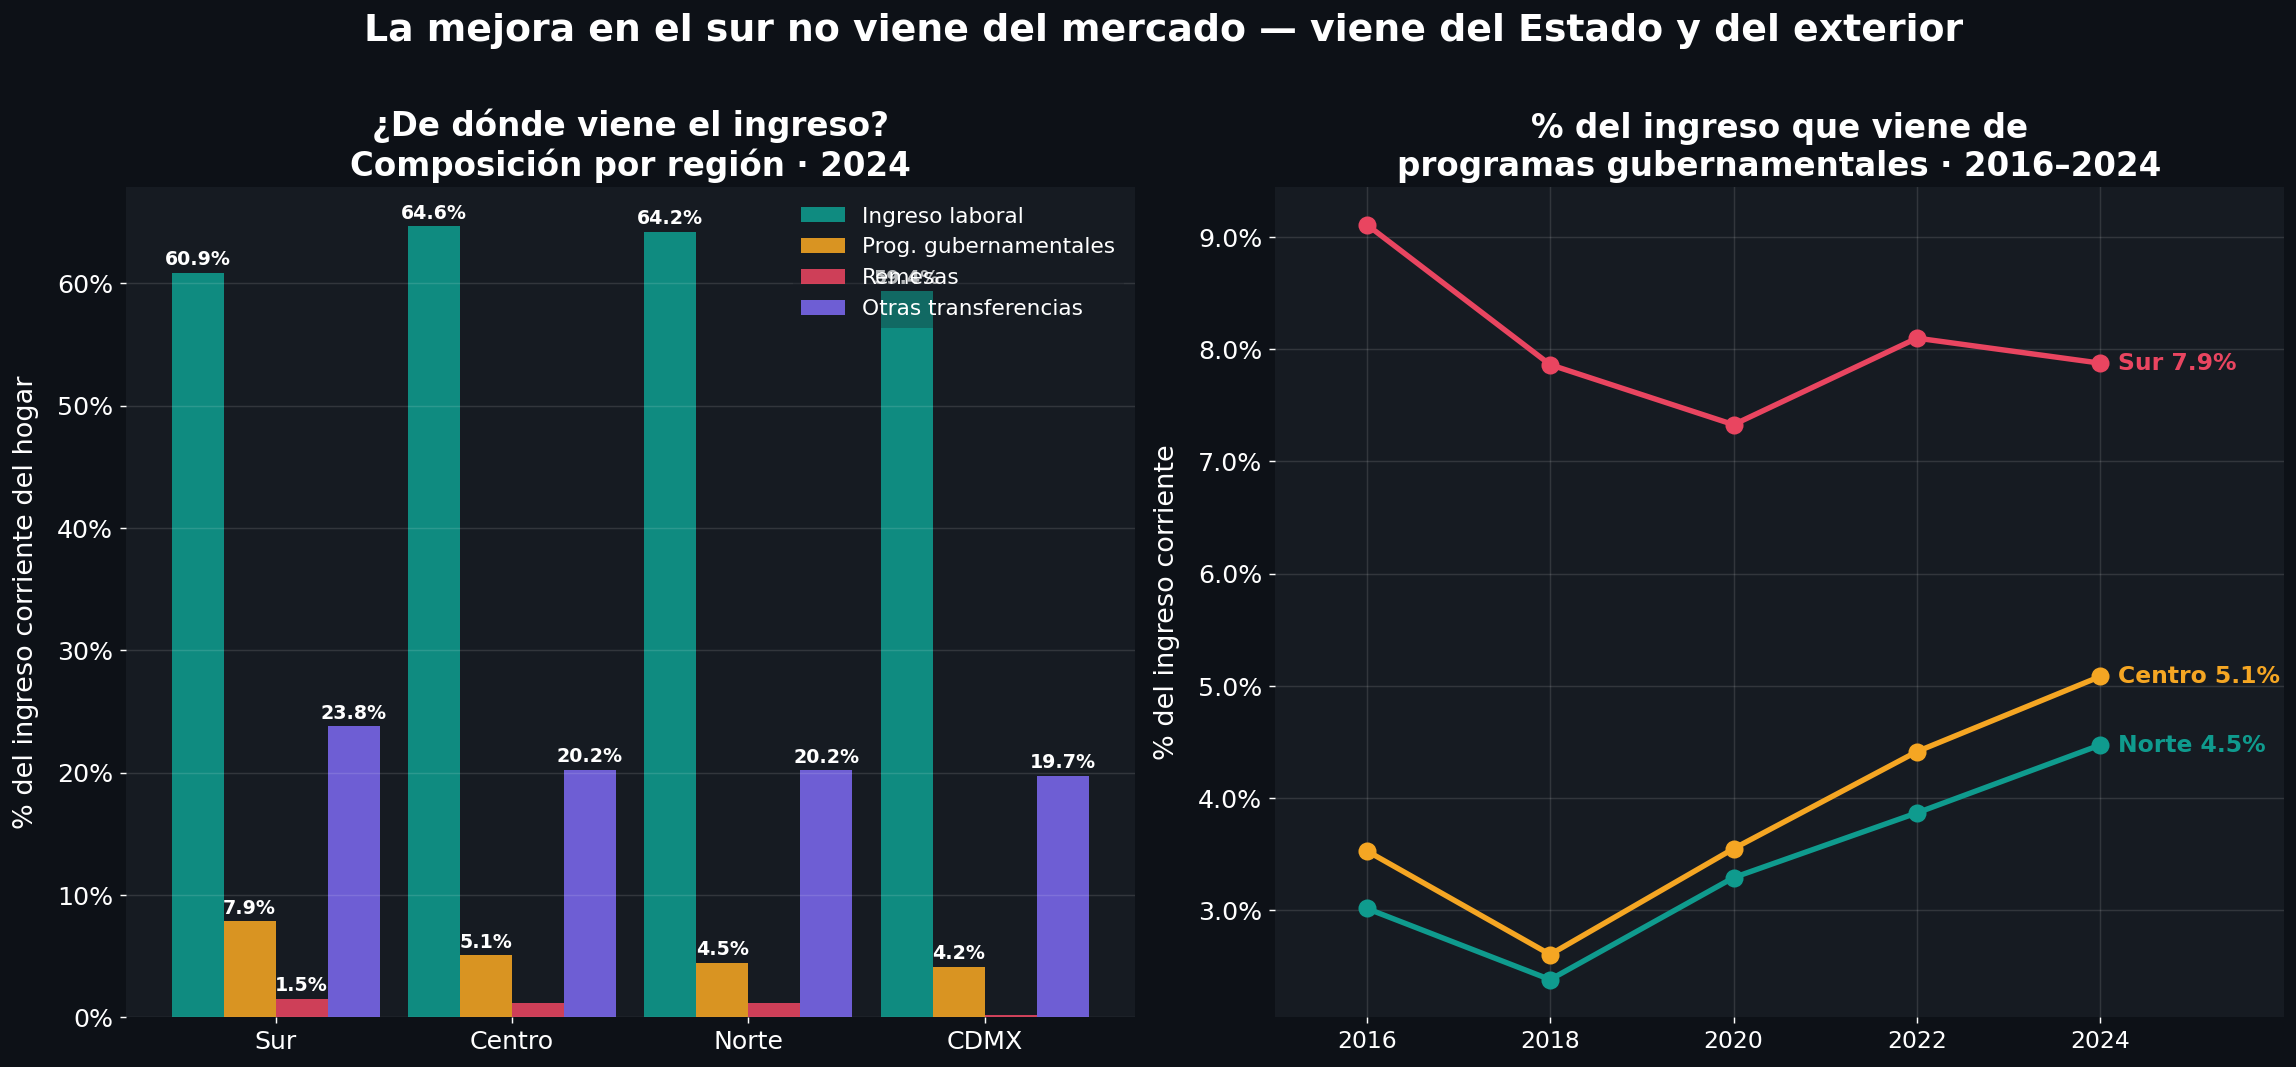

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(BG)

# Panel izquierdo: composición del ingreso por región en 2024
ax = axes[0]
ax.set_facecolor(CARD)
regiones_ord = ["Sur","Centro","Norte","CDMX"]
x = np.arange(len(regiones_ord)); w = 0.22

comp_2024 = enigh_reg[enigh_reg["anio"]==2024].set_index("region")

comps = [
    ("pct_ingtrab",  "Ingreso laboral",        TEAL),
    ("pct_bene_gob", "Prog. gubernamentales",  GOLD),
    ("pct_remesas",  "Remesas",                ACCENT),
    ("pct_transfer", "Otras transferencias",   PURPLE),
]

for i, (col, label, color) in enumerate(comps):
    vals = [comp_2024.loc[r, col] if r in comp_2024.index else 0 for r in regiones_ord]
    bars = ax.bar(x + (i-1.5)*w, vals, w, label=label,
                  color=color, edgecolor="none", alpha=0.88)
    for bar, v in zip(bars, vals):
        if v > 1.5:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f"{v:.1f}%", ha="center", va="bottom", fontsize=10.5,
                    color="white", fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(regiones_ord, fontsize=14)
ax.set_ylabel("% del ingreso corriente del hogar", fontsize=15, labelpad=10)
ax.set_title("¿De dónde viene el ingreso?\nComposición por región · 2024",
             fontsize=18, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.legend(fontsize=12, framealpha=0.3, edgecolor="none", loc="upper right")
ax.grid(axis="y", alpha=0.12, color="white")

# Panel derecho: evolución de bene_gob por región 2016-2024
ax2 = axes[1]
ax2.set_facecolor(CARD)
for region in ["Norte","Centro","Sur"]:
    sub = enigh_reg[enigh_reg["region"]==region].sort_values("anio")
    col = REGION_COLORS[region]
    ax2.plot(sub["anio"], sub["pct_bene_gob"], marker="o", color=col,
             linewidth=3, markersize=9, zorder=5)
    ultimo = sub.iloc[-1]
    ax2.annotate(f"{region} {ultimo['pct_bene_gob']:.1f}%",
                 xy=(ultimo["anio"], ultimo["pct_bene_gob"]),
                 xytext=(10, 0), textcoords="offset points",
                 color=col, fontsize=13, fontweight="bold", va="center")

ax2.set_title("% del ingreso que viene de\nprogramas gubernamentales · 2016–2024",
              fontsize=18, fontweight="bold")
ax2.set_ylabel("% del ingreso corriente", fontsize=15, labelpad=10)
ax2.set_xticks([2016,2018,2020,2022,2024])
ax2.set_xticklabels(["2016","2018","2020","2022","2024"], fontsize=13)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.1f}%"))
ax2.grid(alpha=0.12, color="white")
ax2.set_xlim(2015, 2026)

fig.suptitle("La mejora en el sur no viene del mercado — viene del Estado y del exterior",
             fontsize=21, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(IMG/"04_composicion_ingreso.png", dpi=150, bbox_inches="tight")
plt.show()


<div style="background:#161b22; padding:24px 36px; border-radius:12px;
     border-left:5px solid #2ecc71; margin:8px 0 8px 0;">
  <p style="color:#c9d1d9;font-size:1.1em;line-height:1.7;margin:0;">
    Los datos regionales muestran la tendencia. Los datos estatales revelan las personas.
    <strong style="color:#2ecc71;">Guerrero es el estado donde una mayor proporción
    del ingreso familiar proviene de remesas</strong> — dinero enviado desde Estados Unidos
    y desde otras ciudades de México por quienes ya no pudieron quedarse.
    No es un dato menor: es la fotografía de un estado que sobrevive de su propia diáspora.
  </p>
</div>

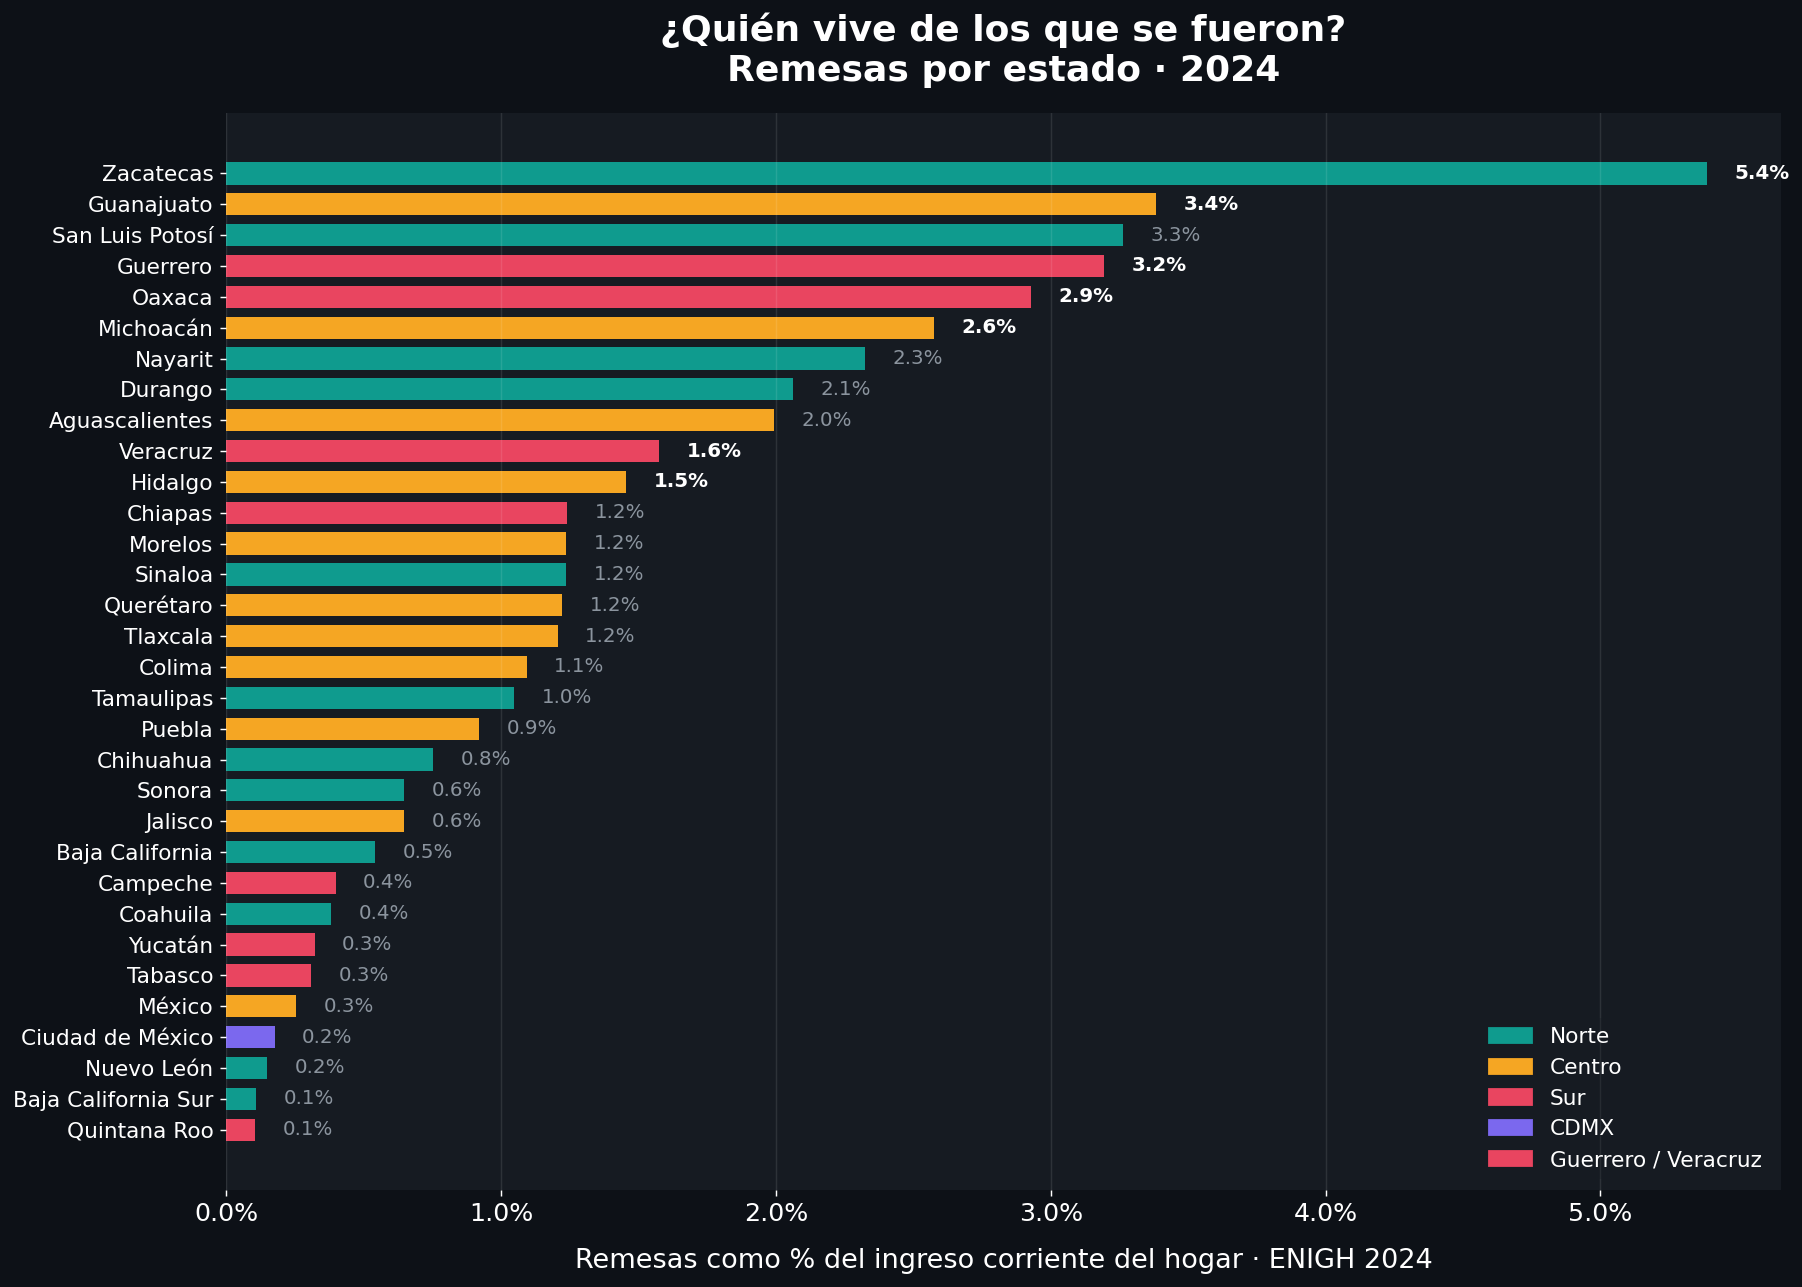

Top 5 estados por % remesas (2024):
         estado  pct_remesas
      Zacatecas     5.387799
     Guanajuato     3.382325
San Luis Potosí     3.262477
       Guerrero     3.194545
         Oaxaca     2.927823


In [10]:
# Remesas por estado — ENIGH 2024 (estado-año)
rem_est = enigh_est[enigh_est["anio"]==2024][["estado","region","pct_remesas"]].dropna()
rem_est = rem_est.sort_values("pct_remesas", ascending=True)

DEST_REM = {"Guerrero","Michoacán","Oaxaca","Veracruz","Hidalgo","Zacatecas","Guanajuato"}

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

colors_rem = []
for _, row in rem_est.iterrows():
    if row["estado"] in ("Guerrero","Veracruz"):
        colors_rem.append(ACCENT)
    else:
        colors_rem.append(REGION_COLORS.get(row["region"], MUTED))

bars_rem = ax.barh(rem_est["estado"], rem_est["pct_remesas"],
                   color=colors_rem, edgecolor="none", height=0.72)

for bar, val, estado in zip(bars_rem, rem_est["pct_remesas"], rem_est["estado"]):
    destacado = estado in DEST_REM
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", ha="left", fontsize=11,
            color="white" if destacado else MUTED,
            fontweight="bold" if destacado else "normal")

ax.set_xlabel("Remesas como % del ingreso corriente del hogar · ENIGH 2024", fontsize=15, labelpad=12)
ax.set_title("¿Quién vive de los que se fueron?\nRemesas por estado · 2024",
             fontsize=20, fontweight="bold", pad=18)
ax.tick_params(axis="y", labelsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.1f}%"))
ax.grid(axis="x", alpha=0.1, color="white", linewidth=0.8)

# Leyenda manual
handles_r = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
handles_r.append(mpatches.Patch(color=ACCENT, label="Guerrero / Veracruz"))
ax.legend(handles=handles_r, loc="lower right", fontsize=12, framealpha=0.3, edgecolor="none")

plt.tight_layout()
plt.savefig(IMG/"04b_remesas_estado.png", dpi=150, bbox_inches="tight")
plt.show()
top5 = rem_est.nlargest(5, "pct_remesas")[["estado","pct_remesas"]]
print("Top 5 estados por % remesas (2024):")
print(top5.to_string(index=False))


<div style="background:linear-gradient(135deg,#1a1a2e,#16213e);
     padding:36px 44px; border-radius:14px; border-left:7px solid #e94560; margin:24px 0 8px 0;">
  <p style="color:#e94560;font-weight:700;letter-spacing:.15em;font-size:.95em;margin:0 0 8px 0;">ACTO V</p>
  <h2 style="color:white;font-size:2.1em;font-weight:900;margin:0 0 16px 0;">
    Los que se van: la fuga de talento que perpetúa el ciclo
  </h2>
  <p style="color:#c9d1d9;font-size:1.15em;line-height:1.75;margin:0;">
    El sur exporta lo único que tiene: a su gente. Los estados con más pobreza
    son los que pierden más población hacia el norte y el centro.
    Cada joven que migra manda remesas — y eso aparece como ingreso,
    como si el estado estuviera mejorando. Pero el estado <em>no mejoró.</em>
    Solo aprendió a vivir de los que ya no están.
    <strong style="color:#e94560;">El dato lo confirma: más pobreza, más emigración.</strong>
  </p>
</div>

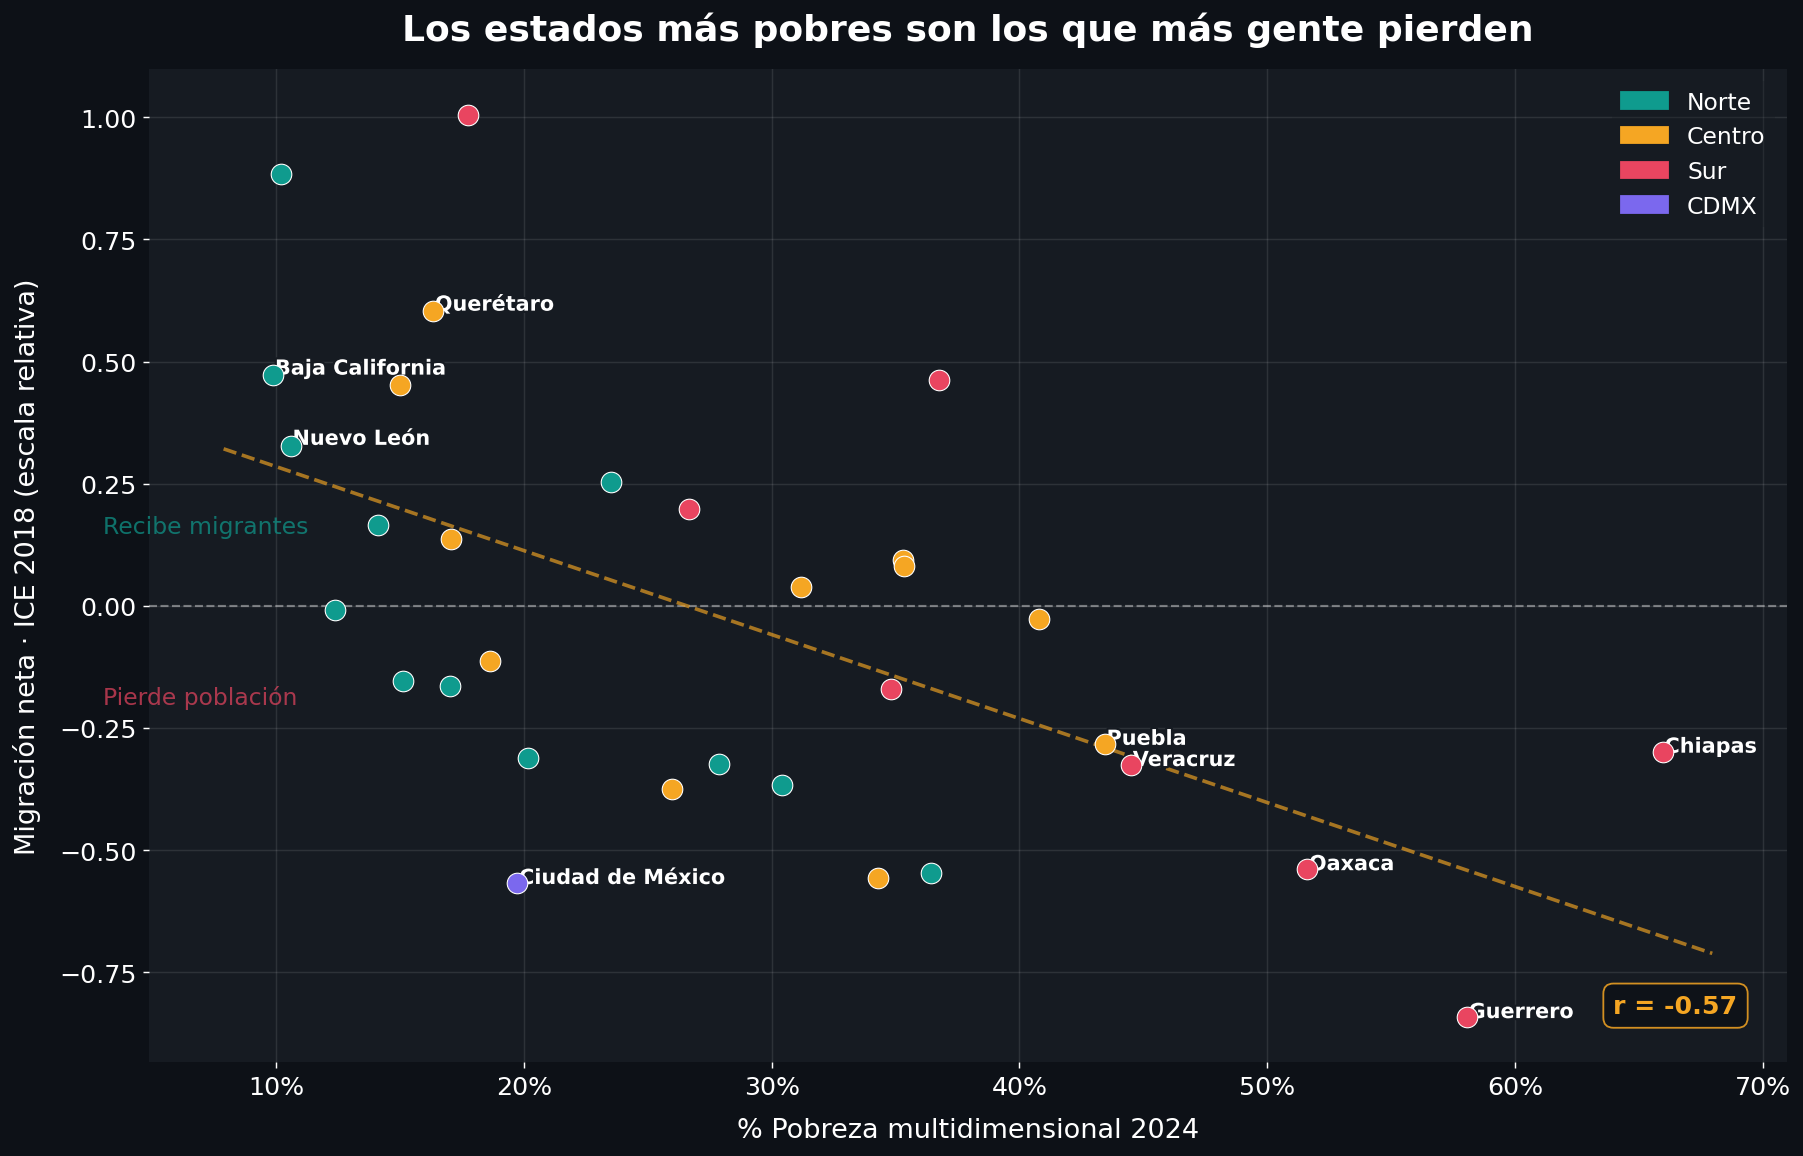

Correlación pobreza × migración: r = -0.57  [negativa (más pobreza → más emigración)]


In [12]:
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

df_mig = maestro.dropna(subset=["ice_migracion","pct_pobreza_2024"]).copy()

ETIQUETAR_MIG = {"Chiapas","Guerrero","Oaxaca","Veracruz","Puebla",
                 "Nuevo León","Ciudad de México","Baja California","Querétaro"}

for _, row in df_mig.iterrows():
    ax.scatter(row["pct_pobreza_2024"], row["ice_migracion"],
               c=row["color"], s=130, zorder=5, edgecolors="white", linewidth=0.6)
    if row["estado"] in ETIQUETAR_MIG:
        # Ajustar offset para evitar superposición
        dy = 0.4 if row["ice_migracion"] > 0 else -0.5
        dx = 1.0
        ax.annotate(row["estado"],
                    (row["pct_pobreza_2024"], row["ice_migracion"]),
                    xytext=(dx, dy), textcoords="offset points",
                    fontsize=11.5, color="white", fontweight="bold",
                    path_effects=[pe.withStroke(linewidth=2.5, foreground=CARD)],
                    xycoords="data",
                    arrowprops=dict(arrowstyle="-", color="white", alpha=0.3, lw=0.8)
                    if abs(row["ice_migracion"]) > 1.5 else None)

ax.axhline(0, color="white", linewidth=1.2, alpha=0.4, linestyle="--")
ax.text(3, 0.15, "Recibe migrantes", color=TEAL, fontsize=13, alpha=0.7)
ax.text(3, -0.2, "Pierde población", color=ACCENT, fontsize=13, alpha=0.7)

z = np.polyfit(df_mig["pct_pobreza_2024"], df_mig["ice_migracion"], 1)
x_l = np.linspace(df_mig["pct_pobreza_2024"].min()-2, df_mig["pct_pobreza_2024"].max()+2, 100)
ax.plot(x_l, np.poly1d(z)(x_l), "--", color=GOLD, alpha=0.65, linewidth=2)

corr = df_mig["pct_pobreza_2024"].corr(df_mig["ice_migracion"])
ax.text(0.97, 0.05, f"r = {corr:.2f}", transform=ax.transAxes,
        fontsize=14, color=GOLD, ha="right", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=BG, edgecolor=GOLD, alpha=0.85))

ax.set_xlabel("% Pobreza multidimensional 2024", fontsize=15, labelpad=10)
ax.set_ylabel("Migración neta · ICE 2018 (escala relativa)", fontsize=15, labelpad=10)
ax.set_title("Los estados más pobres son los que más gente pierden",
             fontsize=20, fontweight="bold", pad=16)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.grid(alpha=0.1, color="white")

handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax.legend(handles=handles, fontsize=13, framealpha=0.3, edgecolor="none")

plt.tight_layout()
plt.savefig(IMG/"05_migracion_pobreza.png", dpi=150, bbox_inches="tight")
plt.show()
direction = "negativa (más pobreza → más emigración)" if corr < 0 else "positiva"
print(f"Correlación pobreza × migración: r = {corr:.2f}  [{direction}]")


<div style="background:#0d1117; padding:36px 44px; border-radius:14px;
     border: 1px solid #30363d; margin:24px 0;">
  <h3 style="color:white;font-size:1.5em;font-weight:800;margin:0 0 24px 0;text-align:center;
             letter-spacing:.05em;">El ciclo que se perpetúa</h3>
  <div style="display:flex;align-items:center;justify-content:center;flex-wrap:wrap;gap:0;">
    <div style="background:#1a1a2e;padding:14px 20px;border-radius:10px;
                border-top:3px solid #e94560;text-align:center;min-width:130px;">
      <div style="color:#e94560;font-weight:800;font-size:1em;">Naces en el Sur</div>
      <div style="color:#8b949e;font-size:.85em;margin-top:4px;">Alta pobreza · r=0.8 con etnicidad</div>
    </div>
    <div style="color:#8b949e;font-size:1.8em;padding:0 8px;">→</div>
    <div style="background:#1a1a2e;padding:14px 20px;border-radius:10px;
                border-top:3px solid #7b68ee;text-align:center;min-width:130px;">
      <div style="color:#7b68ee;font-weight:800;font-size:1em;">Empleo informal</div>
      <div style="color:#8b949e;font-size:.85em;margin-top:4px;">&gt;60% informalidad · ICE 2018</div>
    </div>
    <div style="color:#8b949e;font-size:1.8em;padding:0 8px;">→</div>
    <div style="background:#1a1a2e;padding:14px 20px;border-radius:10px;
                border-top:3px solid #f5a623;text-align:center;min-width:130px;">
      <div style="color:#f5a623;font-weight:800;font-size:1em;">Bajos ingresos</div>
      <div style="color:#8b949e;font-size:.85em;margin-top:4px;">1.4× menos que el Norte · ENIGH 2024</div>
    </div>
    <div style="color:#8b949e;font-size:1.8em;padding:0 8px;">→</div>
    <div style="background:#1a1a2e;padding:14px 20px;border-radius:10px;
                border-top:3px solid #0f9b8e;text-align:center;min-width:130px;">
      <div style="color:#0f9b8e;font-weight:800;font-size:1em;">Migras</div>
      <div style="color:#8b949e;font-size:.85em;margin-top:4px;">Correlación pobreza–emigración</div>
    </div>
    <div style="color:#8b949e;font-size:1.8em;padding:0 8px;">→</div>
    <div style="background:#1a1a2e;padding:14px 20px;border-radius:10px;
                border-top:3px solid #2ecc71;text-align:center;min-width:130px;">
      <div style="color:#2ecc71;font-weight:800;font-size:1em;">Mandas remesas</div>
      <div style="color:#8b949e;font-size:.85em;margin-top:4px;">Guerrero: top 1 nacional · ENIGH 2024</div>
    </div>
    <div style="color:#8b949e;font-size:1.8em;padding:0 8px;">→</div>
    <div style="background:#1a1a2e;padding:14px 20px;border-radius:10px;
                border-top:3px solid #e94560;text-align:center;min-width:130px;">
      <div style="color:#e94560;font-weight:800;font-size:1em;">El estado "mejora"</div>
      <div style="color:#8b949e;font-size:.85em;margin-top:4px;">Pero la brecha no cierra</div>
    </div>
  </div>
  <p style="color:#8b949e;font-size:.9em;text-align:center;margin:20px 0 0 0;">
    Cada eslabón está respaldado por datos de fuentes oficiales independientes.
    El ciclo no es un accidente — es la arquitectura del sistema.
  </p>
</div>

<div style="background:linear-gradient(135deg,#1a1a2e,#16213e);
     padding:36px 44px; border-radius:14px; border-left:7px solid #f5a623; margin:24px 0 8px 0;">
  <p style="color:#f5a623;font-weight:700;letter-spacing:.15em;font-size:.95em;margin:0 0 8px 0;">ACTO VI</p>
  <h2 style="color:white;font-size:2.1em;font-weight:900;margin:0 0 16px 0;">
    ¿Está cambiando? ¿A qué ritmo?
  </h2>
  <p style="color:#c9d1d9;font-size:1.15em;line-height:1.75;margin:0;">
    Comparamos el ingreso de cada estado en 2016 con el de 2024.
    Los puntos arriba de la diagonal mejoraron. Los debajo, empeoraron.
    Pero la pregunta no es si mejoró —  la pregunta es si la brecha se cerró.
  </p>
</div>

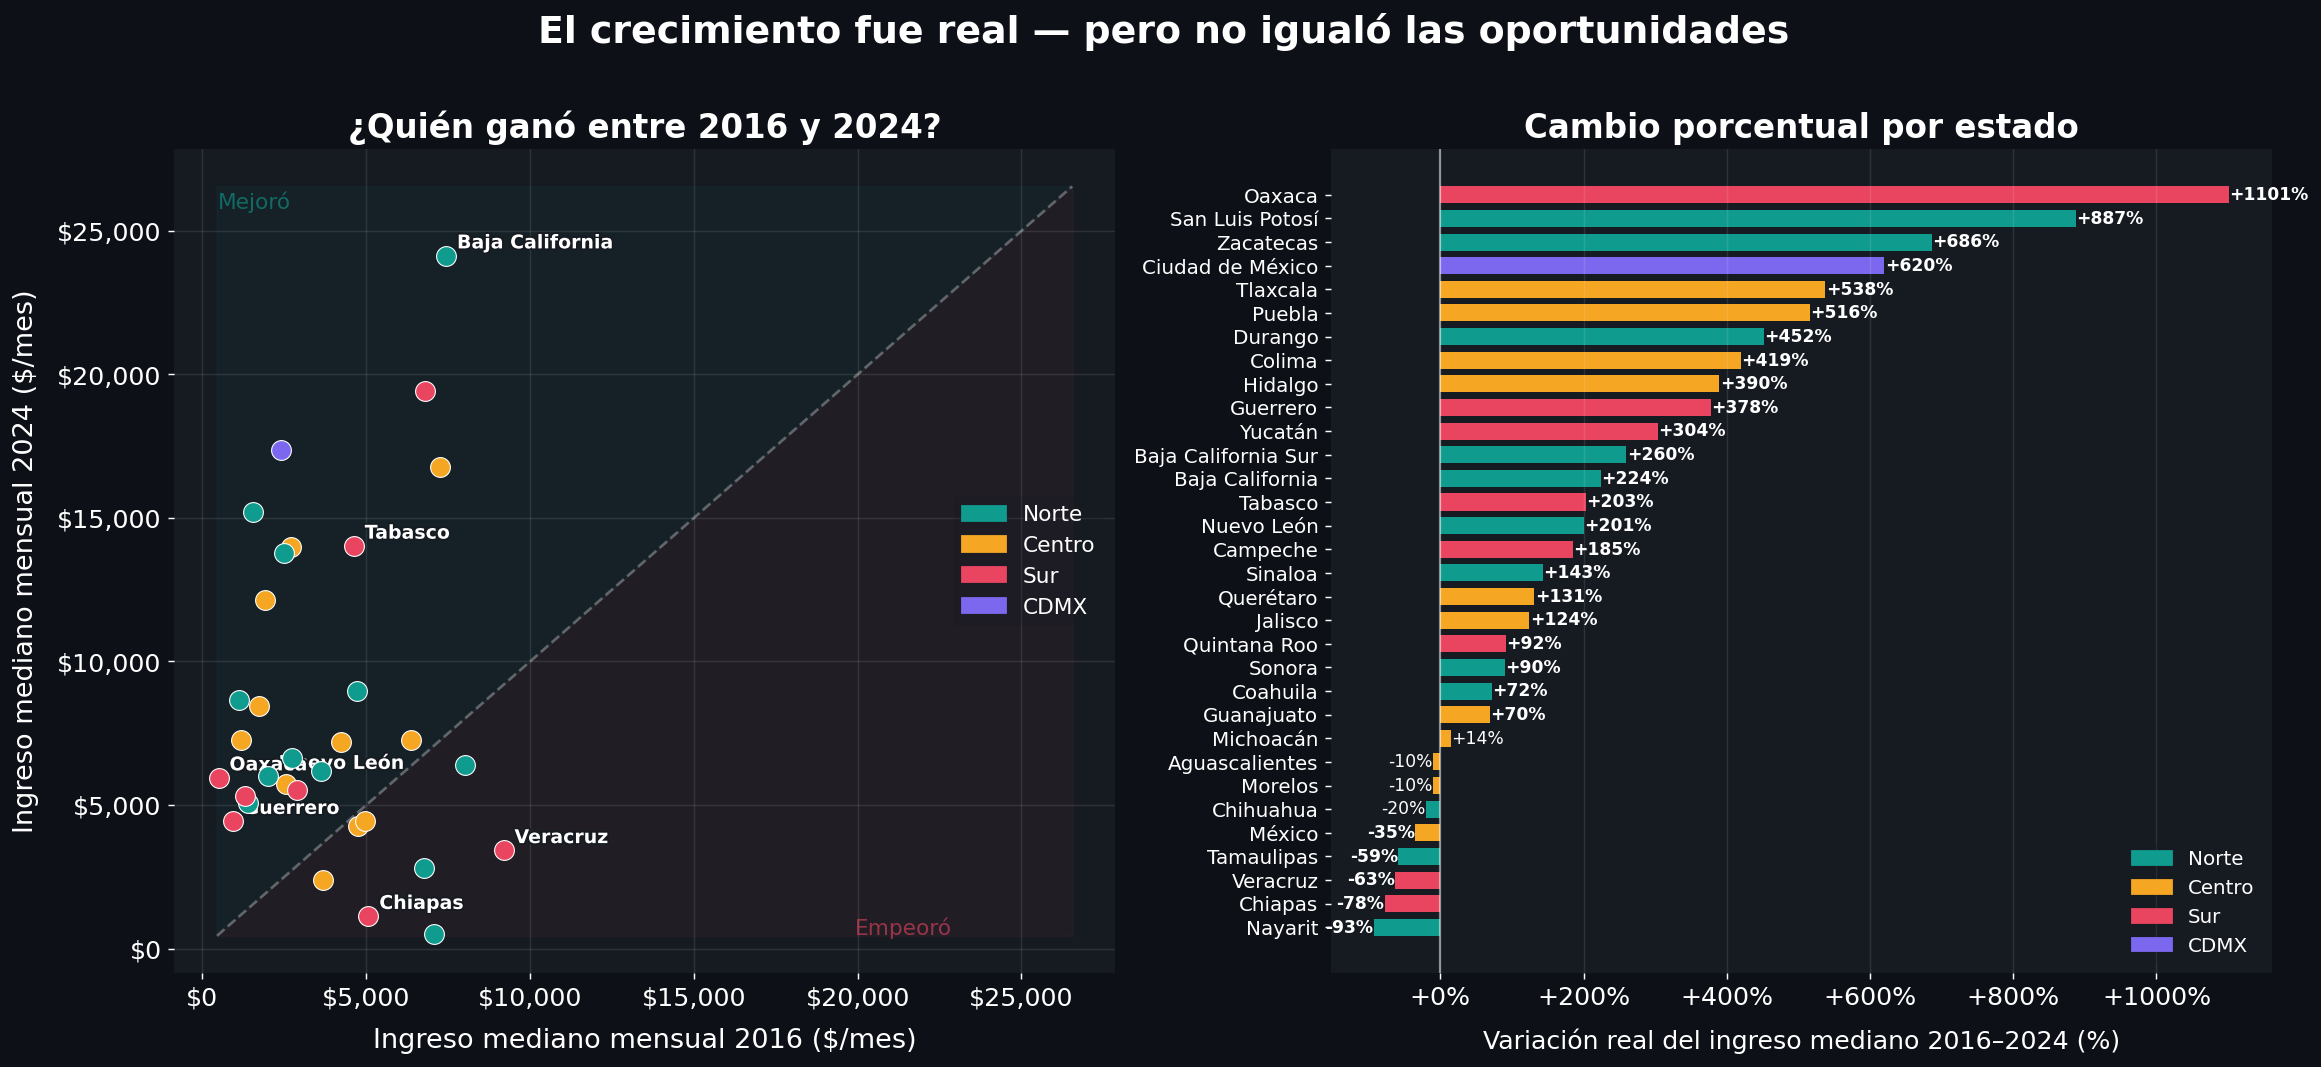

Proyección de convergencia Norte-Sur: año 2019 (regresión lineal sobre la brecha)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(BG)

# Panel izquierdo: scatter 2016 vs 2024 por estado
ax = axes[0]
ax.set_facecolor(CARD)

e16 = enigh_est[enigh_est["anio"]==2016].set_index("estado")["ing_pc_mediana"]
e24 = enigh_est[enigh_est["anio"]==2024].set_index("estado")["ing_pc_mediana"]
comun = e16.index.intersection(e24.index)

df_conv = pd.DataFrame({"ing_2016": e16[comun], "ing_2024": e24[comun]}).reset_index()
df_conv["region"] = df_conv["estado"].map(REGIONES).fillna("Otro")
df_conv["color"]  = df_conv["region"].map(REGION_COLORS).fillna("gray")
df_conv["mejora"] = df_conv["ing_2024"] / df_conv["ing_2016"]

lim_min = min(df_conv["ing_2016"].min(), df_conv["ing_2024"].min()) * 0.9
lim_max = max(df_conv["ing_2016"].max(), df_conv["ing_2024"].max()) * 1.1

ax.plot([lim_min, lim_max], [lim_min, lim_max], "--", color="white", alpha=0.3, linewidth=1.5)
ax.fill_between([lim_min, lim_max], [lim_min, lim_max], lim_max,
                color=TEAL, alpha=0.05)
ax.fill_between([lim_min, lim_max], lim_min, [lim_min, lim_max],
                color=ACCENT, alpha=0.05)
ax.text(lim_min*1.05, lim_max*0.97, "Mejoró", color=TEAL, fontsize=12, alpha=0.6)
ax.text(lim_max*0.75, lim_min*1.08, "Empeoró", color=ACCENT, fontsize=12, alpha=0.6)

ETIQUETAR_C = {"Chiapas","Guerrero","Oaxaca","Nuevo León","Baja California","Veracruz","Tabasco"}
for _, row in df_conv.iterrows():
    ax.scatter(row["ing_2016"], row["ing_2024"],
               c=row["color"], s=120, zorder=5, edgecolors="white", linewidth=0.6)
    if row["estado"] in ETIQUETAR_C:
        ax.annotate(row["estado"],
                    (row["ing_2016"], row["ing_2024"]),
                    xytext=(6, 4), textcoords="offset points",
                    fontsize=10.5, color="white", fontweight="bold",
                    path_effects=[pe.withStroke(linewidth=2, foreground=CARD)])

ax.set_xlabel("Ingreso mediano mensual 2016 ($/mes)", fontsize=15, labelpad=10)
ax.set_ylabel("Ingreso mediano mensual 2024 ($/mes)", fontsize=15, labelpad=10)
ax.set_title("¿Quién ganó entre 2016 y 2024?", fontsize=18, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.grid(alpha=0.1, color="white")

handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax.legend(handles=handles, fontsize=12, framealpha=0.25, edgecolor="none")

# Panel derecho: % de cambio ordenado por región
ax2 = axes[1]
ax2.set_facecolor(CARD)
df_conv_sorted = df_conv.sort_values("mejora", ascending=True)
colors2 = [REGION_COLORS.get(r, MUTED) for r in df_conv_sorted["region"]]
bars3 = ax2.barh(df_conv_sorted["estado"],
                 (df_conv_sorted["mejora"]-1)*100,
                 color=colors2,
                 edgecolor="none", height=0.72)
ax2.axvline(0, color="white", linewidth=1.2, alpha=0.5)
for bar, val in zip(bars3, (df_conv_sorted["mejora"]-1)*100):
    x_pos = val + 0.5 if val >= 0 else val - 0.5
    ha = "left" if val >= 0 else "right"
    ax2.text(x_pos, bar.get_y()+bar.get_height()/2,
             f"{val:+.0f}%", va="center", ha=ha, fontsize=9.5,
             color="white", fontweight="bold" if abs(val) > 30 else "normal")

ax2.set_xlabel("Variación real del ingreso mediano 2016–2024 (%)", fontsize=14, labelpad=10)
ax2.set_title("Cambio porcentual por estado", fontsize=18, fontweight="bold")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:+.0f}%"))
ax2.tick_params(axis="y", labelsize=11)
ax2.grid(axis="x", alpha=0.1, color="white")
ax2.legend(handles=handles, fontsize=11, framealpha=0.25, edgecolor="none",
           loc="lower right")

fig.suptitle("El crecimiento fue real — pero no igualó las oportunidades",
             fontsize=21, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(IMG/"06_convergencia.png", dpi=150, bbox_inches="tight")
plt.show()

# Proyección de convergencia Norte-Sur
años_data = enigh_reg[enigh_reg["region"]=="Norte"].sort_values("anio")["anio"].values
norte_s = enigh_reg[enigh_reg["region"]=="Norte"].sort_values("anio")["ing_pc_mediana"].values
sur_s   = enigh_reg[enigh_reg["region"]=="Sur"].sort_values("anio")["ing_pc_mediana"].values
brechas_t = norte_s - sur_s
z_brecha = np.polyfit(años_data, brechas_t, 1)
if z_brecha[0] < 0:
    año_conv = int(-z_brecha[1] / z_brecha[0])
    print(f"Proyección de convergencia Norte-Sur: año {año_conv} (regresión lineal sobre la brecha)")
else:
    año_conv = None
    print("La brecha Norte-Sur NO converge al ritmo actual (tendencia creciente o estable)")


<div style="background:linear-gradient(135deg,#1a1a2e,#16213e);
     padding:36px 44px; border-radius:14px; border-left:7px solid #0f9b8e; margin:24px 0 8px 0;">
  <p style="color:#0f9b8e;font-weight:700;letter-spacing:.15em;font-size:.95em;margin:0 0 8px 0;">PANORAMA COMPLETO</p>
  <h2 style="color:white;font-size:2.1em;font-weight:900;margin:0 0 16px 0;">
    Los 32 estados bajo una misma lente
  </h2>
  <p style="color:#c9d1d9;font-size:1.15em;line-height:1.75;margin:0;">
    Cada indicador por separado cuenta una parte de la historia. Juntos, revelan el patrón:
    los mismos estados aparecen siempre arriba en pobreza, informalidad, remesas e inseguridad alimentaria.
    No es azar. Es estructura.
  </p>
</div>

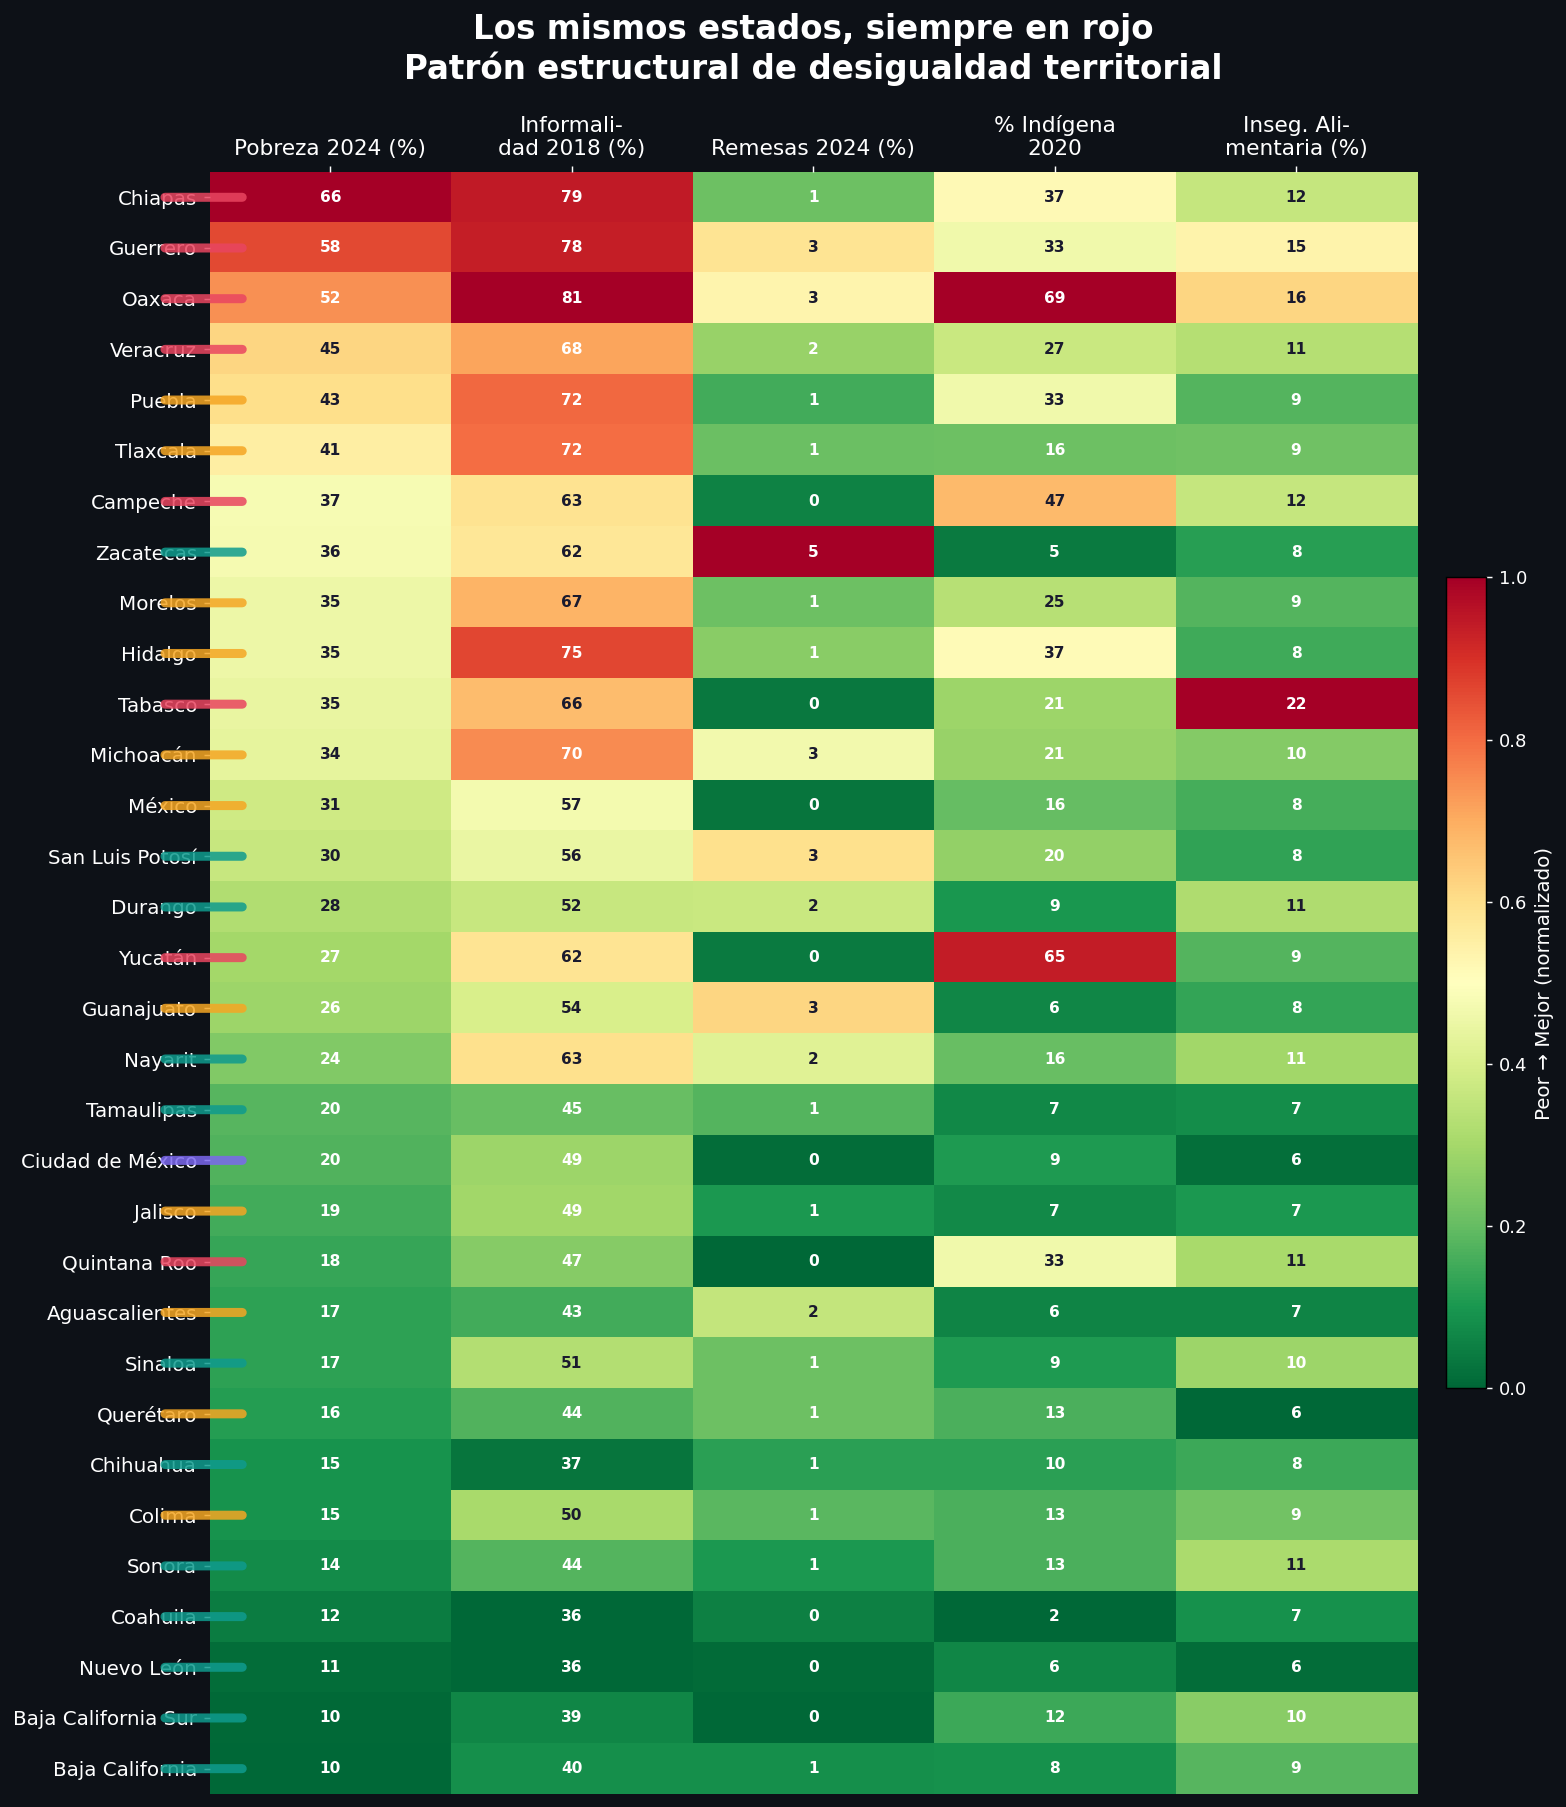

In [14]:
# Heatmap de 32 estados × 5 indicadores clave (normalizados)
indicadores = {
    "Pobreza 2024 (%)":        "pct_pobreza_2024",
    "Informali-\ndad 2018 (%)": "ice_informalidad",
    "Remesas 2024 (%)":        "pct_remesas",
    "% Indígena\n2020":        "pct_indigena",
    "Inseg. Ali-\nmentaria (%)":"pct_inseg_alim",
}
df_heat = maestro[["estado","region"] + list(indicadores.values())].dropna().copy()
df_heat = df_heat.sort_values("pct_pobreza_2024", ascending=False)

mat = df_heat[list(indicadores.values())].values.astype(float)
mat_norm = (mat - mat.min(axis=0)) / (mat.max(axis=0) - mat.min(axis=0) + 1e-9)

fig, ax = plt.subplots(figsize=(13, 14))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

im = ax.imshow(mat_norm, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=1)

ax.set_xticks(range(len(indicadores)))
ax.set_xticklabels(list(indicadores.keys()), fontsize=12, color="white")
ax.set_yticks(range(len(df_heat)))
ax.set_yticklabels(df_heat["estado"].values, fontsize=11, color="white")
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
ax.xaxis.set_label_position("top")

# Color lateral por región
for i, (_, row) in enumerate(df_heat.iterrows()):
    ax.annotate("", xy=(-0.7, i), xytext=(-0.35, i),
                xycoords=("data","data"), textcoords=("data","data"),
                arrowprops=dict(arrowstyle="-", color=REGION_COLORS.get(row["region"],"gray"),
                                lw=5, alpha=0.85))

# Anotaciones de valor en cada celda
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat[i, j]
        txt_color = "white" if mat_norm[i,j] > 0.7 or mat_norm[i,j] < 0.3 else "#1a1a2e"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                fontsize=8.5, color=txt_color, fontweight="bold")

cbar = plt.colorbar(im, ax=ax, shrink=0.5, pad=0.02)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.set_label("Peor → Mejor (normalizado)", color="white", fontsize=11)

ax.set_title("Los mismos estados, siempre en rojo\nPatrón estructural de desigualdad territorial",
             fontsize=18, fontweight="bold", color="white", pad=20)
ax.spines[:].set_visible(False)
ax.tick_params(colors="white")

plt.tight_layout()
plt.savefig(IMG/"07_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


<div style="background:linear-gradient(160deg,#0d1117,#1a1a2e,#16213e);
     padding:52px 48px; border-radius:16px; margin:24px 0 0 0;
     border: 1px solid #30363d;">
  <h2 style="color:white;font-size:2.4em;font-weight:900;line-height:1.2;margin:0 0 24px 0;">
    El talento está en todo México.<br>
    <span style="color:#e94560;">Lo que no está distribuido igual son las oportunidades.</span>
  </h2>
  <p style="color:#c9d1d9;font-size:1.15em;line-height:1.85;margin:0 0 20px 0;max-width:800px;">
    México se comprometió con la Agenda 2030. Al ritmo actual, los estados del sur
    tardarán décadas en alcanzar los niveles de bienestar del norte. No porque su gente
    sea menos trabajadora o menos capaz — sino porque las instituciones, el mercado de trabajo,
    el acceso a educación y salud de calidad llevan generaciones concentrándose en el norte.
  </p>
  <p style="color:#c9d1d9;font-size:1.15em;line-height:1.85;margin:0 0 28px 0;max-width:800px;">
    Los datos son claros: la pobreza territorial en México tiene raíces históricas,
    estructurales y étnicas. Mientras el análisis se limite al promedio nacional,
    la desigualdad seguirá invisible. Los ODS exigen desagregarla.
  </p>
  <div style="display:flex;gap:32px;flex-wrap:wrap;margin-top:12px;">
    <div style="background:#1a1a2e;padding:20px 28px;border-radius:10px;border-top:3px solid #e94560;min-width:180px;">
      <div style="color:#e94560;font-size:2em;font-weight:900;margin-bottom:4px;">~56 pts</div>
      <div style="color:#8b949e;font-size:.95em;">Brecha de pobreza<br>Chiapas vs Baja California</div>
    </div>
    <div style="background:#1a1a2e;padding:20px 28px;border-radius:10px;border-top:3px solid #f5a623;min-width:180px;">
      <div style="color:#f5a623;font-size:2em;font-weight:900;margin-bottom:4px;">1.4×</div>
      <div style="color:#8b949e;font-size:.95em;">El Norte gana más<br>que el Sur (2024)</div>
    </div>
    <div style="background:#1a1a2e;padding:20px 28px;border-radius:10px;border-top:3px solid #0f9b8e;min-width:180px;">
      <div style="color:#0f9b8e;font-size:2em;font-weight:900;margin-bottom:4px;">r ≈ 0.8</div>
      <div style="color:#8b949e;font-size:.95em;">Correlación etnicidad<br>× pobreza (Censo × PM 2024)</div>
    </div>
    <div style="background:#1a1a2e;padding:20px 28px;border-radius:10px;border-top:3px solid #7b68ee;min-width:180px;">
      <div style="color:#7b68ee;font-size:2em;font-weight:900;margin-bottom:4px;">6 eslabones</div>
      <div style="color:#8b949e;font-size:.95em;">Del ciclo de pobreza<br>respaldados por datos</div>
    </div>
  </div>

  <div style="margin-top:36px;padding-top:28px;border-top:1px solid #30363d;max-width:820px;">
    <h3 style="color:white;font-size:1.25em;font-weight:800;margin:0 0 14px 0;">¿Qué implica esto para la política pública?</h3>
    <p style="color:#c9d1d9;font-size:1.05em;line-height:1.75;margin:0 0 10px 0;">
      Los datos muestran que invertir en reducir la pobreza nacional sin desagregar
      por entidad federativa es ineficiente: los recursos se diluyen en estados que
      ya tienen capacidad de recuperación, mientras los estados del sur permanecen
      atrapados en el ciclo. La convergencia requiere intervenciones asimétricas —
      mayor inversión en formalización laboral, acceso a educación superior y
      reducción de inseguridad alimentaria exactamente en los estados donde
      la correlación etnicidad–pobreza es más alta.
    </p>
    <p style="color:#c9d1d9;font-size:1.05em;line-height:1.75;margin:0;">
      La Agenda 2030 no pide promedios. Pide que nadie se quede atrás.
      <strong style="color:#e94560;">Este análisis muestra que en México, el lugar
      donde naciste todavía decide si te quedas o te vas — y si te vas, si regresas.</strong>
    </p>
  </div>

  <p style="color:#8b949e;font-size:1em;margin:32px 0 0 0;">
    ASHIRA · HackODS UNAM 2026 · ODS 1 + ODS 10<br>
    Fuentes: ENIGH 2016–2024 · PM 2024 · Censo 2020 · ICE IMCO 2020 (datos 2018) — INEGI / IMCO / CONEVAL
  </p>
</div>